# EDA Completo — Sentinel-5P · Cali Metropolitano (2020–2024)

**GeoVision-CLIP Cali** — Análisis Exploratorio de Datos unificado.

- **14,533 GeoTIFFs** leídos en una sola pasada
- **28 visualizaciones** organizadas en bloques temáticos
- Productos: NO₂, SO₂, O₃ (Sentinel-5P L3) + datos DAGMA


## ⚙️ 1. Imports y Configuración

In [6]:
import os, sys, logging, warnings, json
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, Patch, FancyBboxPatch
import seaborn as sns
from scipy import stats
from scipy.ndimage import uniform_filter1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import rasterio
from rasterio.warp import transform_bounds
from rasterio.features import geometry_mask

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
warnings.filterwarnings('ignore')

# ── Rutas del proyecto ──────────────────────────────────
PROJECT_DIR = Path().resolve().parent.parent  # ajustar según estructura
DATA_DIR    = PROJECT_DIR / 'data'
S5P_L3_DIR  = DATA_DIR / 'sentinel5p' / 'l3'
DAGMA_GEOJSON = DATA_DIR / 'dagma' / 'estaciones_dagma.geojson'
DAGMA_RAW_DIR = DATA_DIR / 'dagma' / 'raw'
OUTPUT_DIR  = PROJECT_DIR / 'outputs' / 'eda' / 'sentinel5p'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Parámetros ──────────────────────────────────────────
YEARS    = [2020, 2021, 2022, 2023, 2024]
PRODUCTS = ['NO2', 'SO2', 'O3']

FULL_BOUNDS  = {'left': -77.00, 'right': -75.79, 'bottom': 2.99, 'top': 5.00}
NROWS, NCOLS = 201, 121
PIXEL_SIZE   = 0.01

CALI_BOUNDS  = {'left': -76.60, 'right': -76.40, 'bottom': 3.30, 'top': 3.55}
YUMBO_BOUNDS = {'left': -76.55, 'right': -76.45, 'bottom': 3.48, 'top': 3.60}

CLOUD_THRESHOLD = 0.3
MOL_TO_UMOL     = 1e6

DPI       = 150
COLOR_NO2 = '#d62728'
COLOR_SO2 = '#ff7f0e'
COLOR_O3  = '#2ca02c'
COLOR_MAP = {'NO2': COLOR_NO2, 'SO2': COLOR_SO2, 'O3': COLOR_O3}

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')
logger = logging.getLogger('EDA-S5P')

try:
    import contextily as ctx; HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("⚠️  contextily no disponible — los mapas base se mostrarán en gris")

try:
    import cartopy.crs as ccrs; import cartopy.feature as cfeature; HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

print("✅ Configuración lista")


✅ Configuración lista


## 🔧 2. Funciones auxiliares

In [7]:
def lonlat_to_pixel(lon, lat):
    col = int(round((lon - FULL_BOUNDS['left']) / PIXEL_SIZE))
    row = int(round((FULL_BOUNDS['top'] - lat) / PIXEL_SIZE))
    return row, col

def bounds_to_slice(bounds):
    r1, c1 = lonlat_to_pixel(bounds['left'], bounds['top'])
    r2, c2 = lonlat_to_pixel(bounds['right'], bounds['bottom'])
    return (slice(max(0, min(r1, r2)), min(NROWS, max(r1, r2))),
            slice(max(0, min(c1, c2)), min(NCOLS, max(c1, c2))))

def pixel_centers(bounds=None):
    if bounds is None: bounds = FULL_BOUNDS
    rs, cs = bounds_to_slice(bounds)
    nrs = rs.stop - rs.start; ncs = cs.stop - cs.start
    lon0 = FULL_BOUNDS['left'] + cs.start * PIXEL_SIZE + PIXEL_SIZE/2
    lat0 = FULL_BOUNDS['top']  - rs.start * PIXEL_SIZE - PIXEL_SIZE/2
    return (np.linspace(lon0, lon0+(ncs-1)*PIXEL_SIZE, ncs),
            np.linspace(lat0, lat0-(nrs-1)*PIXEL_SIZE, nrs))

def safe_read_raster(filepath):
    try:
        with rasterio.open(filepath) as src:
            return src.read(1).astype(np.float64), src.transform, src.crs, src.bounds
    except Exception as e:
        logger.warning(f'Error reading {filepath}: {e}')
        return None, None, None, None

def add_basemap(ax, bounds_dict, zoom=12, alpha=0.6):
    if not HAS_CTX: ax.set_facecolor('#f0f0f0'); return
    try:
        ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron,
                        alpha=alpha, zoom=zoom, attribution=False)
    except: ax.set_facecolor('#f0f0f0')

def load_dagma_stations():
    if not DAGMA_GEOJSON.exists(): return gpd.GeoDataFrame()
    gdf = gpd.read_file(DAGMA_GEOJSON)
    gdf['lon'] = gdf.geometry.x; gdf['lat'] = gdf.geometry.y
    return gdf

def add_stations_to_map(ax, stations_gdf, highlight_industrial=True):
    if stations_gdf.empty: return
    d = stations_gdf[stations_gdf['red'] == 'DAGMA']
    if not d.empty:
        ax.scatter(d['lon'], d['lat'], c='black', s=35, marker='^',
                   edgecolors='white', linewidth=0.5, zorder=10, label='DAGMA')
    if highlight_industrial:
        c = stations_gdf[stations_gdf['red'] == 'CVC']
        if not c.empty:
            ax.scatter(c['lon'], c['lat'], c='darkorange', s=45, marker='s',
                       edgecolors='white', linewidth=0.5, zorder=10, label='CVC')
    for _, r in stations_gdf.iterrows():
        ax.annotate(r.get('nombre','')[:15], (r['lon'], r['lat']),
                    textcoords="offset points", xytext=(5,-10),
                    fontsize=5, color='dimgray', ha='left')

def label_bbox(ax, text, x, y, color='black', fontsize=8, **kw):
    ax.annotate(text, xy=(x,y), fontsize=fontsize, color=color, weight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))

def compute_rolling_mean(series, window=30, min_periods=5):
    return pd.Series(series).rolling(window=window, min_periods=min_periods, center=True).mean()

def build_date_inventory():
    logger.info('Construyendo inventario de fechas...')
    date_dirs = []
    for yd in sorted(S5P_L3_DIR.iterdir()):
        if not yd.is_dir(): continue
        try: year = int(yd.name)
        except: continue
        if year not in YEARS: continue
        for md in sorted(yd.iterdir()):
            if not md.is_dir(): continue
            for dd in sorted(md.iterdir()):
                if not dd.is_dir(): continue
                try: m, d = int(md.name), int(dd.name); dt = datetime(year, m, d)
                except: continue
                date_dirs.append((dt, year, m, d, dd))
    date_dirs.sort(key=lambda x: x[0])
    logger.info(f'  → {len(date_dirs)} fechas ({date_dirs[0][0].date()} a {date_dirs[-1][0].date()})')
    return date_dirs

print("✅ Funciones auxiliares definidas")


✅ Funciones auxiliares definidas


## 📥 3. Carga y acumulación de datos (una sola pasada)

In [8]:
def accumulate_s5p_data(date_inventory):
    """Una sola pasada sobre todos los archivos S5P."""
    n_dates = len(date_inventory)
    logger.info(f'Procesando {n_dates} fechas en UNA pasada...')

    cali_rs, cali_cs = bounds_to_slice(CALI_BOUNDS)

    no2_sum = np.zeros((NROWS, NCOLS), dtype=np.float64)
    no2_cnt = np.zeros((NROWS, NCOLS), dtype=np.float64)
    so2_sum = np.zeros((NROWS, NCOLS), dtype=np.float64)
    so2_cnt = np.zeros((NROWS, NCOLS), dtype=np.float64)
    o3_sum  = np.zeros((NROWS, NCOLS), dtype=np.float64)
    o3_cnt  = np.zeros((NROWS, NCOLS), dtype=np.float64)

    valid_pixel_count  = np.zeros((NROWS, NCOLS), dtype=np.float64)
    total_days_read    = 0
    no2_cover_by_year  = {y: np.zeros((NROWS, NCOLS), dtype=np.float64) for y in YEARS}
    cloud_by_year      = {y: [] for y in YEARS}

    no2_sv  = {y: np.zeros((NROWS, NCOLS)) for y in YEARS}
    no2_cv  = {y: np.zeros((NROWS, NCOLS)) for y in YEARS}
    no2_sd  = {y: np.zeros((NROWS, NCOLS)) for y in YEARS}
    no2_sd2 = {y: np.zeros((NROWS, NCOLS)) for y in YEARS}
    no2_sxy = {y: np.zeros((NROWS, NCOLS)) for y in YEARS}

    daily_records = []
    daily_cov_cali = []
    processed = 0; skipped = 0

    for idx, (dt, yr, mo, dy, day_dir) in enumerate(date_inventory):
        files = {p: day_dir / f'{p}.tif' for p in ['NO2','SO2','O3','CLOUD']}
        if not files['CLOUD'].exists(): skipped += 1; continue

        arrays = {}
        for p in ['NO2','SO2','O3','CLOUD']:
            if not files[p].exists(): arrays[p] = None; continue
            d,_,_,_ = safe_read_raster(files[p])
            arrays[p] = d if (d is not None and d.shape == (NROWS, NCOLS)) else None
        if arrays['CLOUD'] is None: skipped += 1; continue

        cloud = arrays['CLOUD']
        qmask = cloud <= CLOUD_THRESHOLD
        total_days_read += 1
        valid_pixel_count += qmask.astype(np.float64)

        no2v = qmask & (arrays['NO2'] > 0) if arrays['NO2'] is not None else np.zeros((NROWS, NCOLS), dtype=bool)
        no2_cover_by_year[yr] += no2v.astype(np.float64)

        cali_q = qmask[cali_rs, cali_cs]
        daily_cov_cali.append((dt, np.sum(cali_q) / cali_q.size * 100))
        cloud_by_year[yr].append(float(np.nanmean(cloud)))

        day_of_year = dt.timetuple().tm_yday

        for p in ['NO2','SO2','O3']:
            if arrays.get(p) is None: continue
            pd_ = arrays[p]
            vm = qmask & (pd_ > 0)
            if p == 'NO2':
                no2_sum += np.where(vm, pd_, 0.0); no2_cnt += vm.astype(np.float64)
                no2_sv[yr] += np.where(vm, pd_, 0.0); no2_cv[yr] += vm.astype(np.float64)
                no2_sd[yr]  += np.where(vm, float(day_of_year), 0.0)
                no2_sd2[yr] += np.where(vm, float(day_of_year)**2, 0.0)
                no2_sxy[yr] += np.where(vm, pd_ * float(day_of_year), 0.0)
            elif p == 'SO2': so2_sum += np.where(vm, pd_, 0.0); so2_cnt += vm.astype(np.float64)
            elif p == 'O3':  o3_sum  += np.where(vm, pd_, 0.0); o3_cnt  += vm.astype(np.float64)

        rec = {'date': dt, 'year': yr, 'month': mo, 'day': dy,
               'weekday': dt.weekday(), 'cloud_mean': float(np.nanmean(cloud))}
        for p in ['NO2','SO2','O3']:
            if arrays.get(p) is None: rec[f'{p}_mean'] = np.nan; continue
            vd = np.where(qmask & (arrays[p] > 0), arrays[p], np.nan)
            with np.errstate(all='ignore'): rec[f'{p}_mean'] = float(np.nanmean(vd))
        daily_records.append(rec)
        processed += 1
        if processed % 200 == 0: logger.info(f'  {processed}/{n_dates}...')

    daily_df = pd.DataFrame(daily_records)
    if not daily_df.empty: daily_df = daily_df.sort_values('date').reset_index(drop=True)
    cov_df = pd.DataFrame(daily_cov_cali, columns=['date','coverage_pct'])

    logger.info('Calculando tendencias anuales por píxel...')
    trend_maps = {}
    for yr in YEARS:
        c = no2_cv[yr]; mask = c > 3
        n, sx, sy, sx2, sxy = [no2_cv[yr][mask], no2_sd[yr][mask], no2_sv[yr][mask],
                                no2_sd2[yr][mask], no2_sxy[yr][mask]]
        denom = n * sx2 - sx * sx
        slp = np.full((NROWS, NCOLS), np.nan)
        valid = denom > 0
        rows, cols = np.where(mask)
        rows_v, cols_v = rows[valid], cols[valid]
        slp[rows_v, cols_v] = (n[valid]*sxy[valid] - sx[valid]*sy[valid]) / denom[valid]
        slp[rows, cols] *= MOL_TO_UMOL * 365.25
        trend_maps[yr] = slp

    logger.info(f'=== RESUMEN: {processed} días procesados, {skipped} omitidos ===')
    for p in PRODUCTS:
        col = f'{p}_mean'
        if col in daily_df.columns:
            v = daily_df[col].dropna()
            logger.info(f'  {p}: {len(v)} días, media={v.mean()*MOL_TO_UMOL:.4f} µmol/m²')

    return {
        'daily_df': daily_df, 'cov_df': cov_df,
        'no2_sum': no2_sum, 'no2_count': no2_cnt,
        'so2_sum': so2_sum, 'so2_count': so2_cnt,
        'o3_sum':  o3_sum,  'o3_count':  o3_cnt,
        'cover_by_year': no2_cover_by_year,
        'cloud_by_year': cloud_by_year,
        'valid_pixel_count': valid_pixel_count,
        'total_days_read':   total_days_read,
        'trend_maps': trend_maps,
        'no2_sumval_by_year': no2_sv, 'no2_count_by_year': no2_cv,
        'n_processed': processed, 'n_skipped': skipped,
        'date_inventory': date_inventory,
    }


In [9]:
# ── Ejecutar carga de datos ─────────────────────────────
stations_gdf   = load_dagma_stations()
print(f"→ {len(stations_gdf)} estaciones DAGMA cargadas")

date_inventory = build_date_inventory()
results        = accumulate_s5p_data(date_inventory)
print(f"✅ {results['n_processed']} días procesados | {results['n_skipped']} omitidos")


15:50:08 [INFO] Construyendo inventario de fechas...


15:50:08 [INFO]   → 1827 fechas (2020-01-01 a 2024-12-31)
15:50:08 [INFO] Procesando 1827 fechas en UNA pasada...


→ 13 estaciones DAGMA cargadas


15:50:12 [INFO]   200/1827...
15:50:16 [INFO]   400/1827...
15:50:19 [INFO]   600/1827...
15:50:23 [INFO]   800/1827...
15:50:27 [INFO]   1000/1827...
15:50:30 [INFO]   1200/1827...
15:50:35 [INFO]   1400/1827...
15:50:38 [INFO]   1600/1827...
15:50:42 [INFO]   1800/1827...
15:50:42 [INFO] Calculando tendencias anuales por píxel...
15:50:42 [INFO] === RESUMEN: 1827 días procesados, 0 omitidos ===
15:50:42 [INFO]   NO2: 1621 días, media=15.4426 µmol/m²
15:50:42 [INFO]   SO2: 1617 días, media=330.3393 µmol/m²
15:50:42 [INFO]   O3: 1775 días, media=115983.7368 µmol/m²


✅ 1827 días procesados | 0 omitidos


---
## 📊 Bloque 1 — Cobertura y Calidad

### Fig 1-1a · Cobertura espacial anual — NO₂

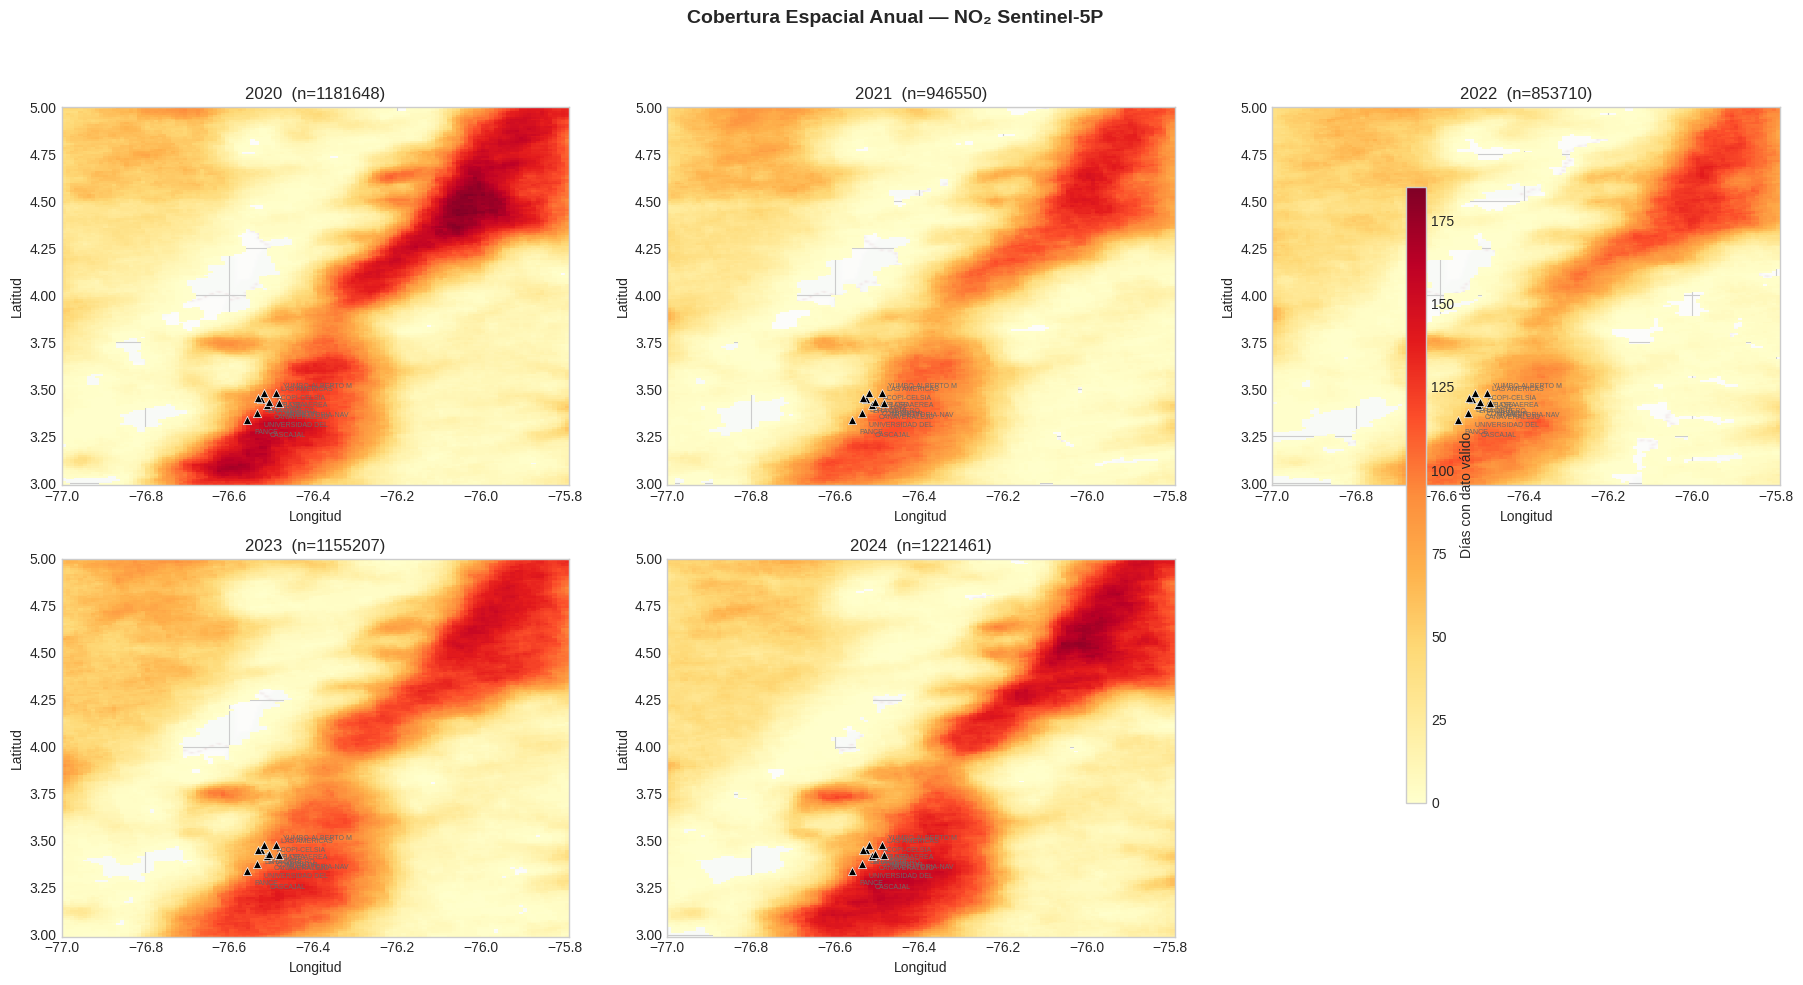

In [10]:
cover = results['cover_by_year']
yrs   = sorted([y for y in YEARS if y in cover and cover[y].sum() > 0])
ncols_p, nrows_p = min(3, len(yrs)), int(np.ceil(len(yrs)/3))

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(6*ncols_p, 5*nrows_p), squeeze=False)
fig.suptitle('Cobertura Espacial Anual — NO₂ Sentinel-5P', fontsize=14, weight='bold')

lons, lats = pixel_centers()
lon_g, lat_g = np.meshgrid(lons, lats)
vmax = max(cover[y].max() for y in yrs)

for i, y in enumerate(yrs):
    r, c = i//ncols_p, i%ncols_p; ax = axes[r][c]
    m  = np.ma.masked_where(cover[y] <= 0, cover[y])
    im = ax.pcolormesh(lon_g, lat_g, m, cmap='YlOrRd', shading='auto', vmin=0, vmax=vmax)
    add_stations_to_map(ax, stations_gdf, False)
    add_basemap(ax, FULL_BOUNDS, 8)
    ax.set_title(f'{y}  (n={cover[y].sum():.0f})')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')

for j in range(len(yrs), nrows_p*ncols_p):
    axes[j//ncols_p][j%ncols_p].set_visible(False)

plt.colorbar(im, ax=axes.ravel().tolist(), label='Días con dato válido', shrink=0.8, aspect=30)
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(OUTPUT_DIR/'fig1_1a_cobertura_anual.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 1-1b · Cobertura temporal mensual

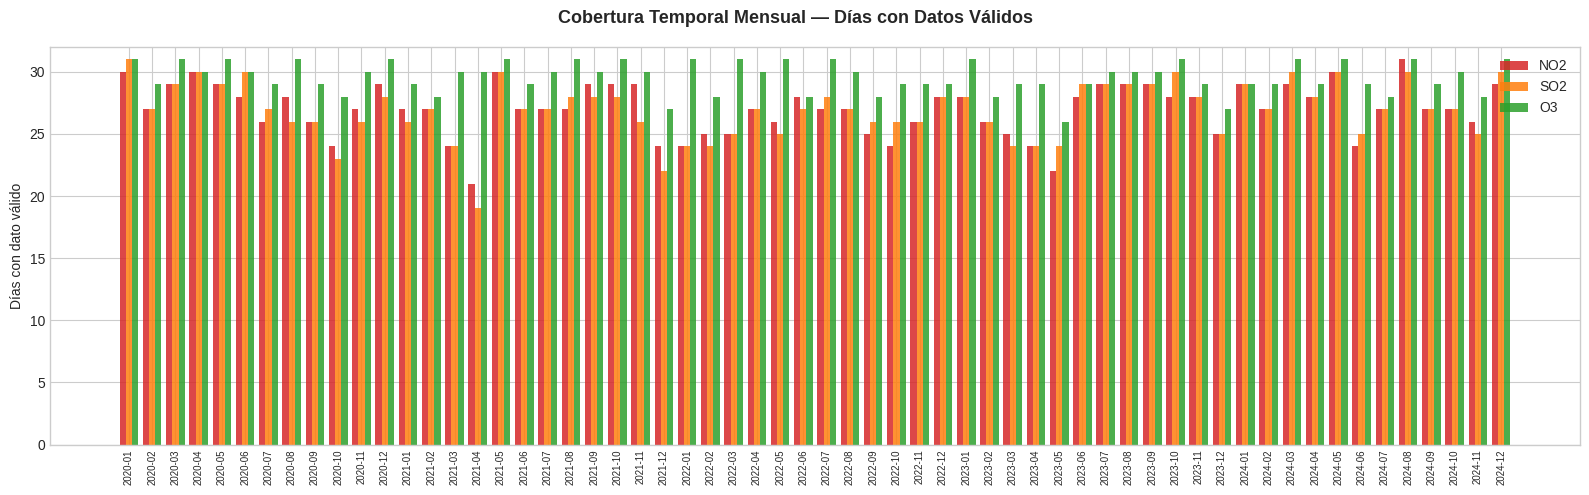

In [11]:
df_tmp = results['daily_df'].copy()
df_tmp['ym'] = df_tmp['date'].dt.to_period('M')

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Cobertura Temporal Mensual — Días con Datos Válidos', fontsize=13, weight='bold')

groups = df_tmp.groupby('ym')
ms     = sorted(groups.groups.keys())
bw     = 0.8 / len(PRODUCTS)

for i, p in enumerate(PRODUCTS):
    cnt = df_tmp.groupby('ym')[f'{p}_mean'].apply(lambda x: x.notna().sum())
    ax.bar(np.arange(len(ms))+i*bw, [cnt.get(m,0) for m in ms],
           width=bw, color=COLOR_MAP[p], alpha=0.85, label=p)

ax.set_xticks(np.arange(len(ms))+bw)
ax.set_xticklabels([str(m) for m in ms], rotation=90, fontsize=7)
ax.set_ylabel('Días con dato válido'); ax.legend(); ax.set_ylim(0,32)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig1_1b_cobertura_temporal.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 1-2 · Evaluación de calidad — fracción de nube

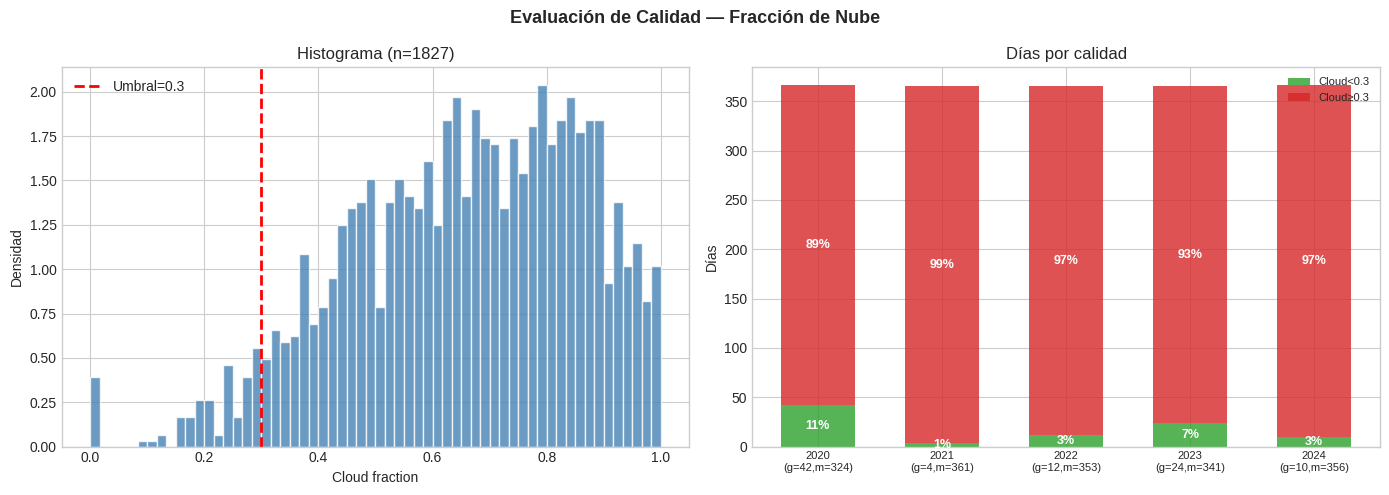

In [12]:
df_tmp = results['daily_df']; cby = results['cloud_by_year']

fig = plt.figure(figsize=(14, 5))
fig.suptitle('Evaluación de Calidad — Fracción de Nube', fontsize=13, weight='bold')

ax1 = fig.add_subplot(1,2,1)
cv  = df_tmp['cloud_mean'].dropna()
ax1.hist(cv, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax1.axvline(CLOUD_THRESHOLD, color='red', ls='--', lw=2, label=f'Umbral={CLOUD_THRESHOLD}')
ax1.set_xlabel('Cloud fraction'); ax1.set_ylabel('Densidad')
ax1.set_title(f'Histograma (n={len(cv)})'); ax1.legend()

ax2  = fig.add_subplot(1,2,2)
yrs2 = sorted(cby.keys()); gd, bd = [], []
for y in yrs2:
    v = np.array(cby[y])
    gd.append(np.sum(v < CLOUD_THRESHOLD)); bd.append(np.sum(v >= CLOUD_THRESHOLD))
x = np.arange(len(yrs2))
ax2.bar(x, gd, 0.6, color='#2ca02c', alpha=0.8, label=f'Cloud<{CLOUD_THRESHOLD}')
ax2.bar(x, bd, 0.6, color='#d62728', alpha=0.8, bottom=gd, label=f'Cloud≥{CLOUD_THRESHOLD}')
for i,(g,b) in enumerate(zip(gd,bd)):
    t = g+b
    ax2.text(i, g/2,   f'{g/t*100:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax2.text(i, g+b/2, f'{b/t*100:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{y}\n(g={g},m={b})' for y,g,b in zip(yrs2,gd,bd)], fontsize=8)
ax2.set_ylabel('Días'); ax2.set_title('Días por calidad'); ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig1_2_calidad_nube.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## 📊 Bloque 2 — Contaminantes

### Fig 2-1a · NO₂ — Serie temporal (2020–2024)

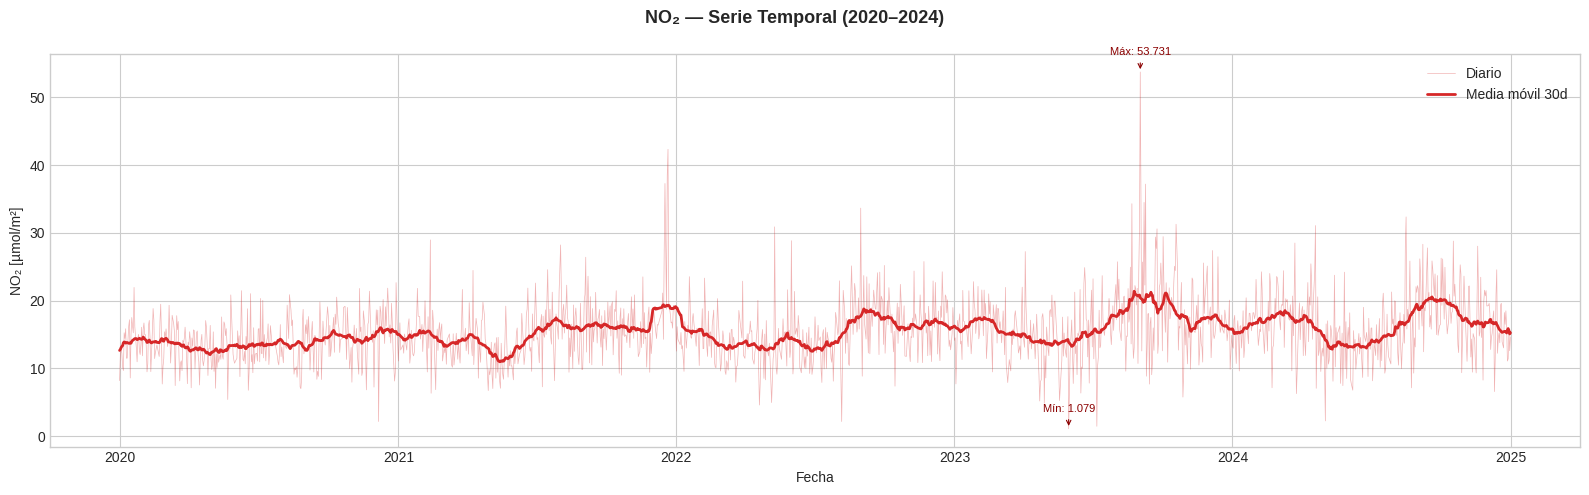

In [13]:
d = results['daily_df'].dropna(subset=['NO2_mean']).copy()
vals  = d['NO2_mean'].values * MOL_TO_UMOL
dates = d['date'].values
roll  = pd.Series(vals).rolling(window=30, min_periods=5, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('NO₂ — Serie Temporal (2020–2024)', fontsize=13, weight='bold')
ax.plot(dates, vals, color=COLOR_NO2, alpha=0.35, lw=0.5, label='Diario')
ax.plot(dates, roll, color=COLOR_NO2, lw=2, label='Media móvil 30d')
ax.set_ylabel('NO₂ [µmol/m²]'); ax.set_xlabel('Fecha'); ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

imx, imn = np.nanargmax(vals), np.nanargmin(vals)
for idx, lbl in [(imx, f'Máx: {vals[imx]:.3f}'), (imn, f'Mín: {vals[imn]:.3f}')]:
    ax.annotate(lbl, (dates[idx], vals[idx]), textcoords="offset points", xytext=(0,12),
                fontsize=8, ha='center', color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_1a_no2_serie_temporal.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-1b · NO₂ — Ciclo estacional y semanal

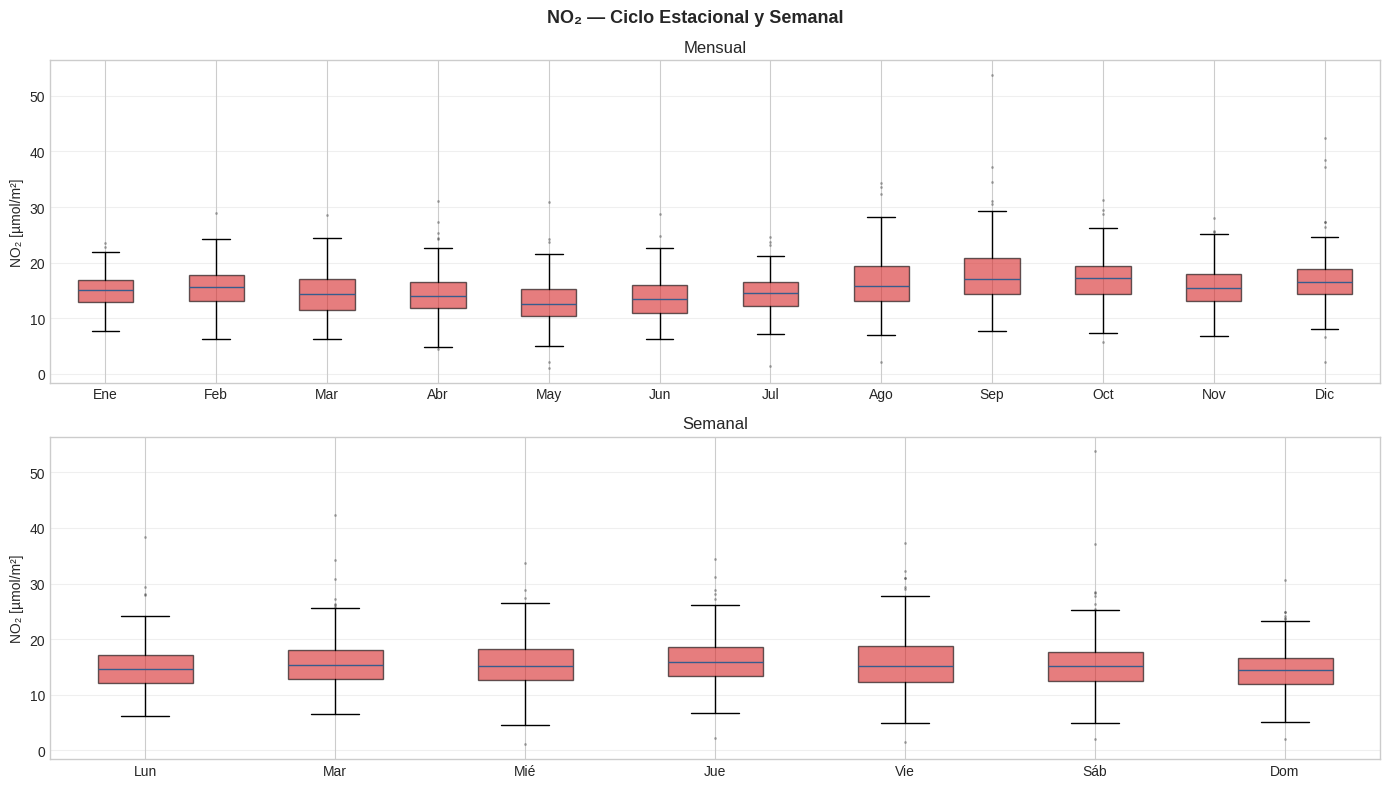

In [14]:
d = results['daily_df'].dropna(subset=['NO2_mean']).copy()
d['v'] = d['NO2_mean'] * MOL_TO_UMOL
d['weekday_name'] = d['date'].dt.day_name()

meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
dias_es   = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dias_ord  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('NO₂ — Ciclo Estacional y Semanal', fontsize=13, weight='bold')

md_list = [d[d['date'].dt.month==m]['v'].dropna().values for m in range(1,13)]
bp1 = ax1.boxplot(md_list, patch_artist=True, showfliers=True, flierprops=dict(marker='.', markersize=2, alpha=0.3))
for p in bp1['boxes']: p.set_facecolor(COLOR_NO2); p.set_alpha(0.6)
ax1.set_xticklabels(meses_es); ax1.set_ylabel('NO₂ [µmol/m²]')
ax1.set_title('Mensual'); ax1.grid(axis='y', alpha=0.3)

wd_list = [d[d['weekday_name']==dd]['v'].dropna().values for dd in dias_ord]
bp2 = ax2.boxplot(wd_list, patch_artist=True, showfliers=True, flierprops=dict(marker='.', markersize=2, alpha=0.3))
for p in bp2['boxes']: p.set_facecolor(COLOR_NO2); p.set_alpha(0.6)
ax2.set_xticklabels(dias_es); ax2.set_ylabel('NO₂ [µmol/m²]')
ax2.set_title('Semanal'); ax2.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_1b_no2_ciclo_estacional.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-1c · NO₂ — Mapa espacial (Cali)

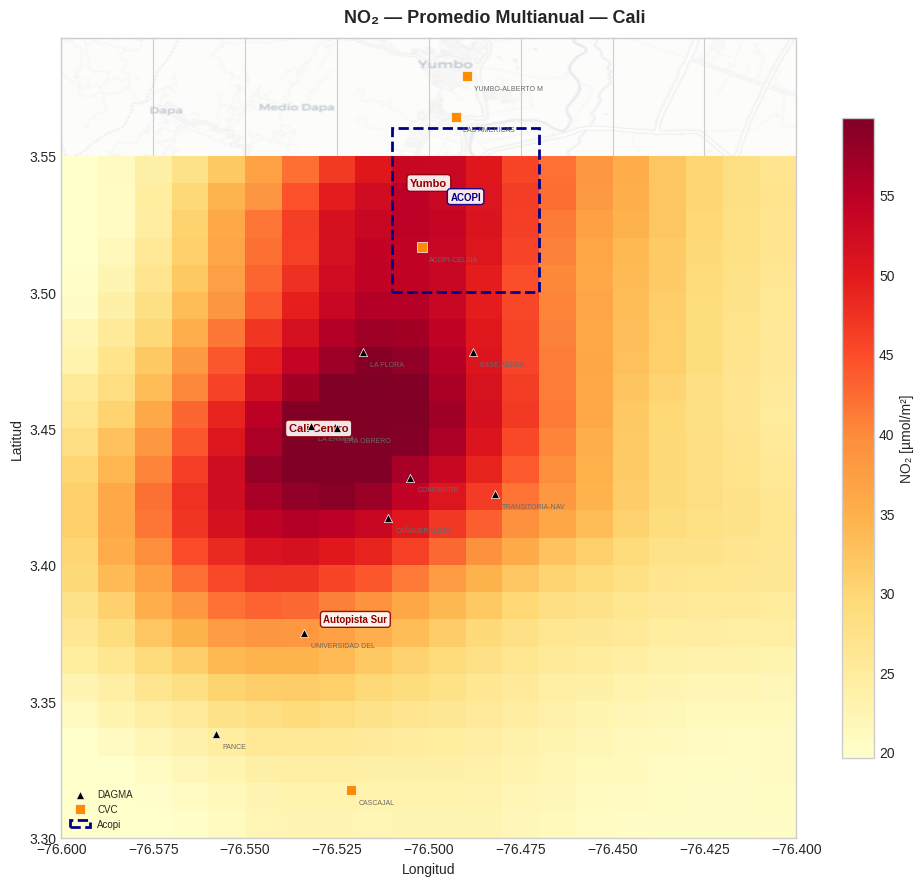

In [15]:
s, c = results['no2_sum'], results['no2_count']
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
f = np.full((NROWS, NCOLS), np.nan); m = c > 0; f[m] = s[m]/c[m]
data = f[rs, cs_sl] * MOL_TO_UMOL
lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('NO₂ — Promedio Multianual — Cali', fontsize=13, weight='bold')
vmin, vmax = np.nanpercentile(data, 2), np.nanpercentile(data, 98)
im = ax.pcolormesh(lon_g, lat_g, data, cmap='YlOrRd', shading='auto', vmin=vmin, vmax=vmax)
add_stations_to_map(ax, stations_gdf, True); add_basemap(ax, CALI_BOUNDS, 12)

label_bbox(ax, 'Yumbo',       -76.50, 3.54, color='darkred', fontsize=8)
label_bbox(ax, 'Cali Centro', -76.53, 3.45, color='darkred', fontsize=8)
label_bbox(ax, 'Autopista Sur',-76.52, 3.38, color='darkred', fontsize=7)
acopi = Rectangle((-76.51, 3.50), 0.04, 0.06, lw=2, edgecolor='darkblue',
                  facecolor='none', ls='--', label='Acopi')
ax.add_patch(acopi)
label_bbox(ax, 'ACOPI', -76.49, 3.535, color='darkblue', fontsize=7)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.legend(loc='lower left', fontsize=7, framealpha=0.9)
plt.colorbar(im, ax=ax, label='NO₂ [µmol/m²]', shrink=0.8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_1c_no2_mapa_espacial.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-1d · NO₂ vs Fracción de nube

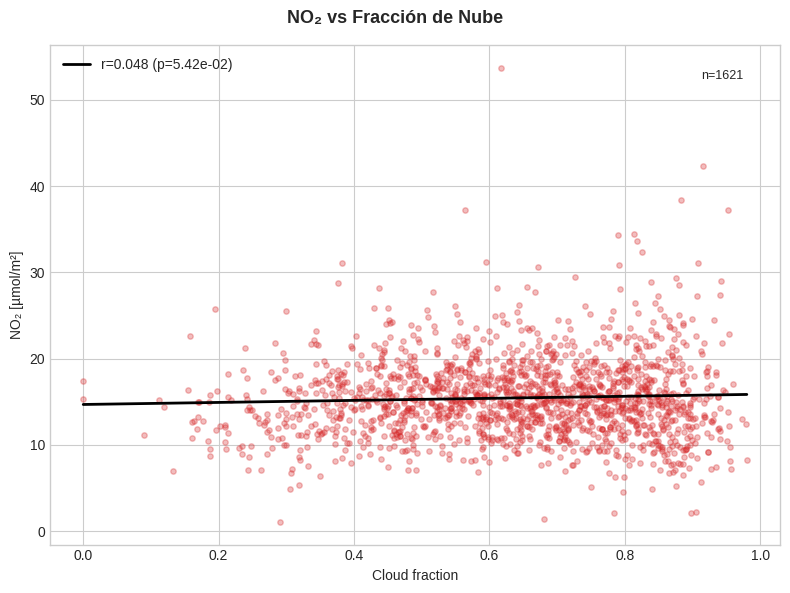

In [16]:
d = results['daily_df'].dropna(subset=['NO2_mean','cloud_mean']).copy()
x, y = d['cloud_mean'].values, d['NO2_mean'].values * MOL_TO_UMOL
slope, intercept, r, p_val, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('NO₂ vs Fracción de Nube', fontsize=13, weight='bold')
ax.scatter(x, y, c=COLOR_NO2, alpha=0.3, s=15)
xf = np.linspace(x.min(), x.max(), 100)
ax.plot(xf, slope*xf+intercept, 'k-', lw=2, label=f'r={r:.3f} (p={p_val:.2e})')
ax.set_xlabel('Cloud fraction'); ax.set_ylabel('NO₂ [µmol/m²]'); ax.legend()
ax.text(0.95, 0.95, f'n={len(d)}', transform=ax.transAxes, ha='right', va='top', fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_1d_no2_vs_nubes.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-2a · SO₂ — Mapa Yumbo / Acopi

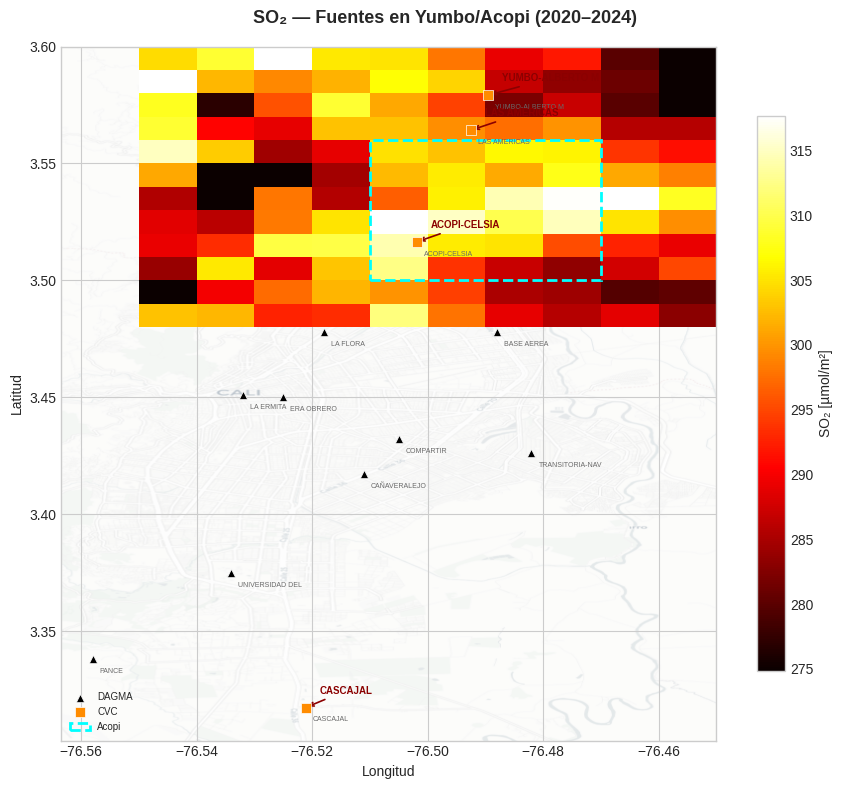

In [17]:
s, c = results['so2_sum'], results['so2_count']
rs, cs_sl = bounds_to_slice(YUMBO_BOUNDS)
f = np.full((NROWS, NCOLS), np.nan); m = c > 0; f[m] = s[m]/c[m]
data = f[rs, cs_sl] * MOL_TO_UMOL
lons, lats = pixel_centers(YUMBO_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle('SO₂ — Fuentes en Yumbo/Acopi (2020–2024)', fontsize=13, weight='bold')
vmin, vmax = np.nanpercentile(data, 5), np.nanpercentile(data, 98)
im = ax.pcolormesh(lon_g, lat_g, data, cmap='hot', shading='auto', vmin=vmin, vmax=vmax)
add_stations_to_map(ax, stations_gdf, True)
cvc = stations_gdf[stations_gdf['red']=='CVC']
for _, r in cvc.iterrows():
    ax.annotate(r.get('nombre','')[:15], (r['lon'], r['lat']),
                textcoords="offset points", xytext=(10,10), fontsize=7,
                color='darkred', weight='bold',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2))
add_basemap(ax, YUMBO_BOUNDS, 13)
acopi = Rectangle((-76.51, 3.50), 0.04, 0.06, lw=2, edgecolor='cyan',
                  facecolor='none', ls='--', label='Acopi')
ax.add_patch(acopi)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud'); ax.legend(loc='lower left', fontsize=7)
plt.colorbar(im, ax=ax, label='SO₂ [µmol/m²]', shrink=0.8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_2a_so2_mapa_yumbo.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-2b · SO₂ — Eventos extremos (p95, p99)

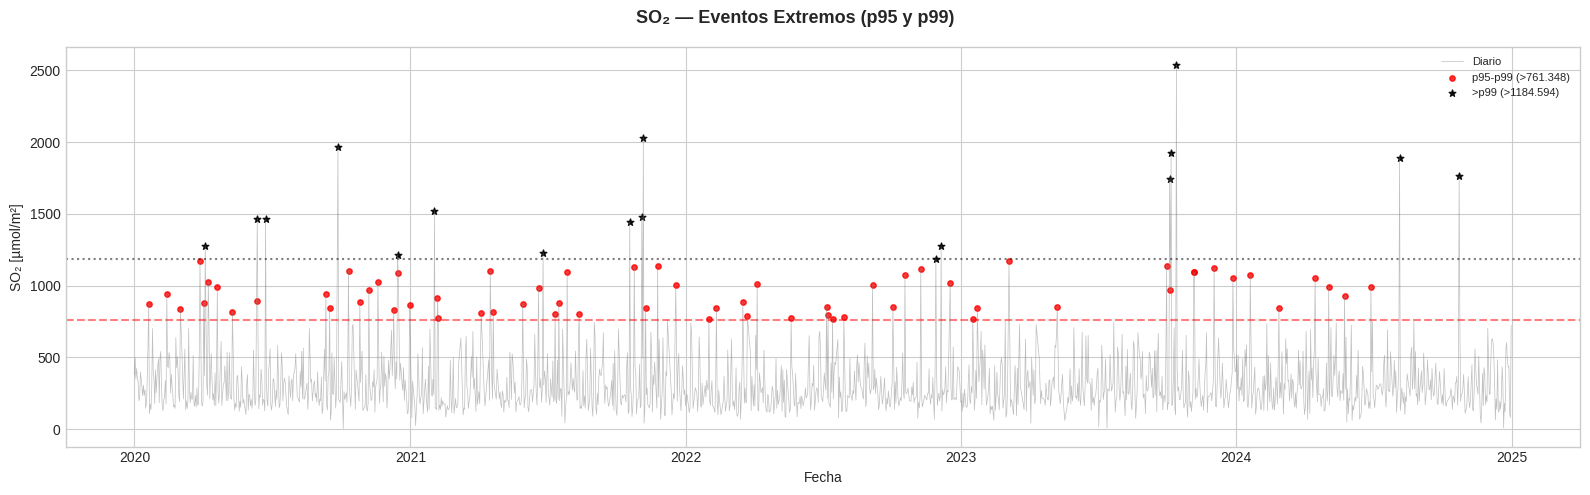

In [18]:
d = results['daily_df'].dropna(subset=['SO2_mean']).copy()
v = d['SO2_mean'].values * MOL_TO_UMOL; dates = d['date'].values
p95, p99 = np.nanpercentile(v, 95), np.nanpercentile(v, 99)
m95 = (v > p95) & (v <= p99); m99 = v > p99

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('SO₂ — Eventos Extremos (p95 y p99)', fontsize=13, weight='bold')
ax.plot(dates, v, color='gray', alpha=0.5, lw=0.5, label='Diario')
ax.scatter(dates[m95], v[m95], c='red',   s=15, alpha=0.8, label=f'p95-p99 (>{p95:.3f})')
ax.scatter(dates[m99], v[m99], c='black', s=25, marker='*', alpha=0.9, label=f'>p99 (>{p99:.3f})')
ax.axhline(p95, color='red',   ls='--', alpha=0.5)
ax.axhline(p99, color='black', ls=':',  alpha=0.5)
ax.set_ylabel('SO₂ [µmol/m²]'); ax.set_xlabel('Fecha'); ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_2b_so2_eventos_extremos.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-3a · O₃ — Ciclo estacional

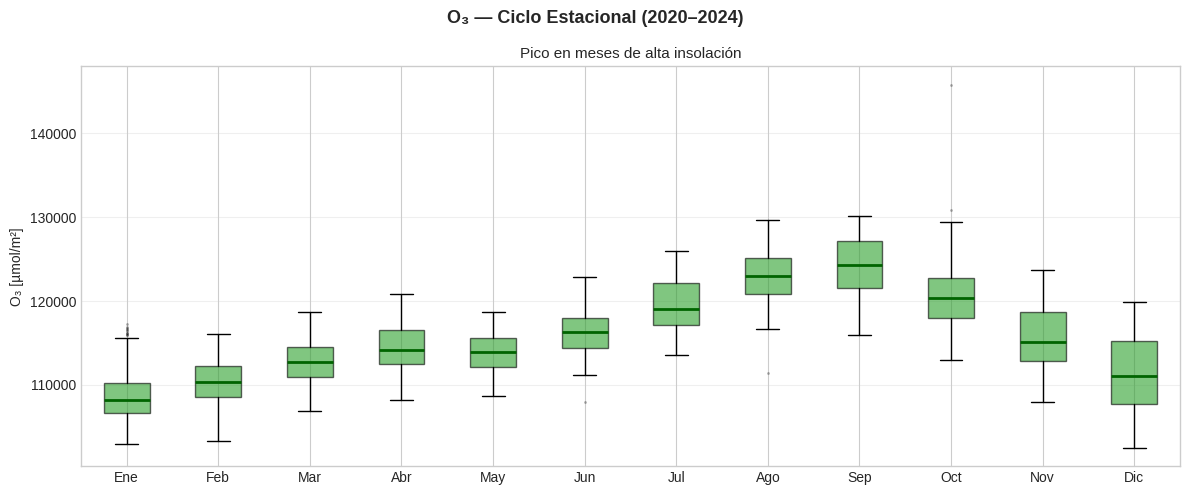

In [19]:
d = results['daily_df'].dropna(subset=['O3_mean']).copy()
d['v'] = d['O3_mean'] * MOL_TO_UMOL
meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
md_list  = [d[d['date'].dt.month==m]['v'].dropna().values for m in range(1,13)]

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('O₃ — Ciclo Estacional (2020–2024)', fontsize=13, weight='bold')
bp = ax.boxplot(md_list, patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for p in bp['boxes']:   p.set_facecolor(COLOR_O3); p.set_alpha(0.6)
for p in bp['medians']: p.set_color('darkgreen');  p.set_linewidth(2)
ax.set_xticklabels(meses_es); ax.set_ylabel('O₃ [µmol/m²]')
ax.set_title('Pico en meses de alta insolación', fontsize=11)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_3a_o3_ciclo_estacional.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-3b · O₃ vs NO₂ — Efecto de titulación

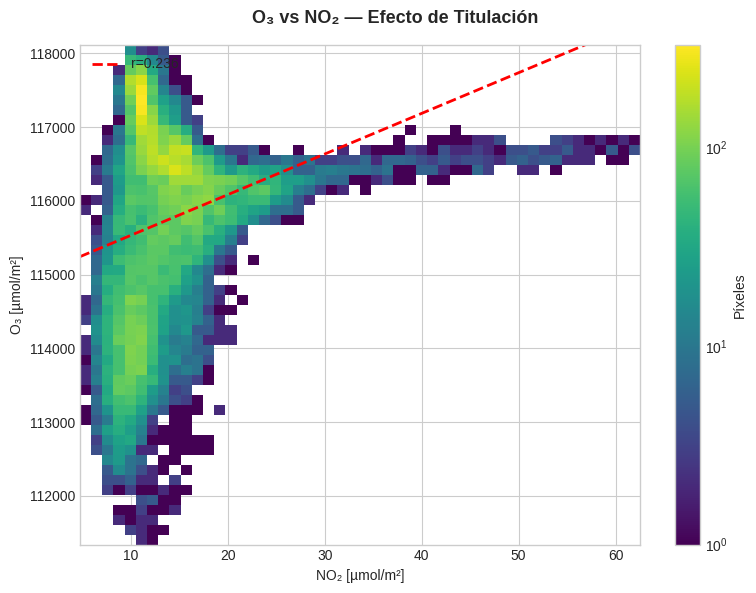

In [20]:
s1, c1 = results['no2_sum'], results['no2_count']
s3, c3 = results['o3_sum'],  results['o3_count']
m = (c1 > 10) & (c3 > 10)
x = (s1[m]/c1[m]*MOL_TO_UMOL).flatten()
y = (s3[m]/c3[m]*MOL_TO_UMOL).flatten()
r, p_val = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('O₃ vs NO₂ — Efecto de Titulación', fontsize=13, weight='bold')
h = ax.hist2d(x, y, bins=50, cmap='viridis', norm=matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Píxeles')
slope, intercept, _, _, _ = stats.linregress(x, y)
xf = np.linspace(x.min(), x.max(), 100)
ax.plot(xf, slope*xf+intercept, 'r--', lw=2, label=f'r={r:.3f}')
ax.set_xlabel('NO₂ [µmol/m²]'); ax.set_ylabel('O₃ [µmol/m²]'); ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_3b_o3_vs_no2_scatter.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 2-3c · O₃ — Mapa espacial (Cali)

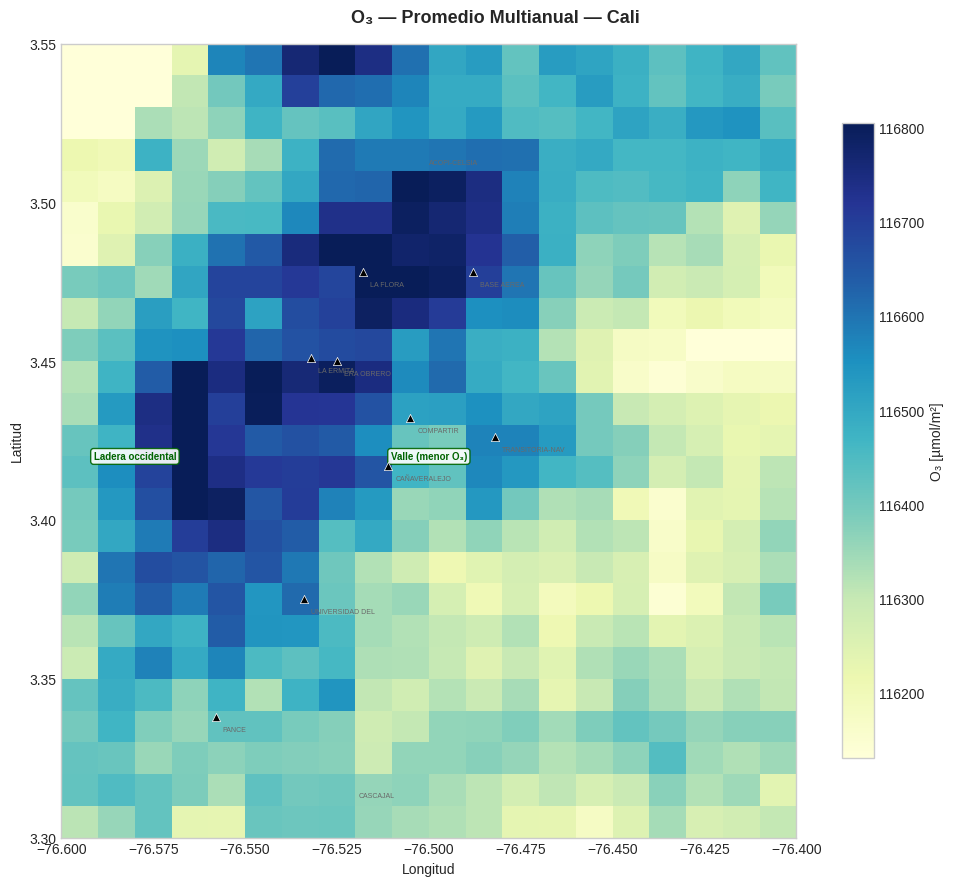

In [21]:
s, c = results['o3_sum'], results['o3_count']
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
f = np.full((NROWS, NCOLS), np.nan); m = c > 0; f[m] = s[m]/c[m]
data = f[rs, cs_sl] * MOL_TO_UMOL
lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('O₃ — Promedio Multianual — Cali', fontsize=13, weight='bold')
vmin, vmax = np.nanpercentile(data, 2), np.nanpercentile(data, 98)
im = ax.pcolormesh(lon_g, lat_g, data, cmap='YlGnBu', shading='auto', vmin=vmin, vmax=vmax)
add_stations_to_map(ax, stations_gdf, False); add_basemap(ax, CALI_BOUNDS, 12)
label_bbox(ax, 'Ladera occidental', -76.58, 3.42, color='darkgreen', fontsize=7)
label_bbox(ax, 'Valle (menor O₃)',  -76.50, 3.42, color='darkgreen', fontsize=7)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.colorbar(im, ax=ax, label='O₃ [µmol/m²]', shrink=0.8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig2_3c_o3_mapa_espacial.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## 📊 Bloque 3 — Integración Multivariada

### Fig 3-1 · Matriz de correlación entre contaminantes

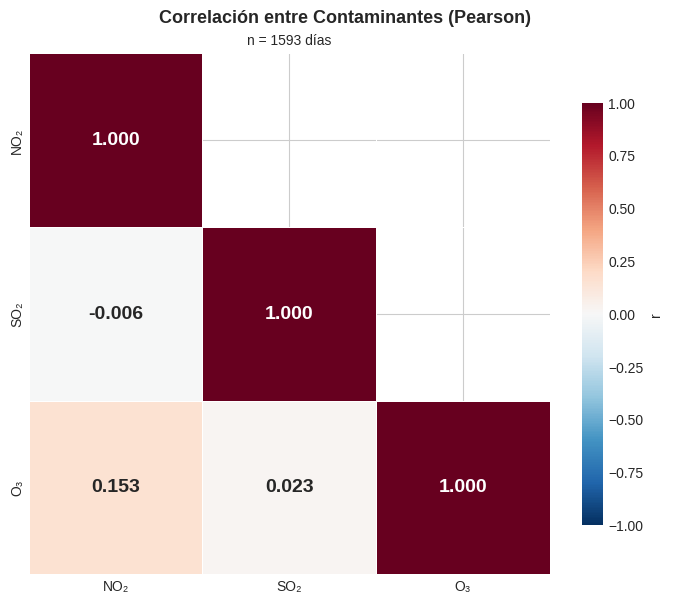

In [22]:
cols = [f'{p}_mean' for p in PRODUCTS]
corr = results['daily_df'][cols].dropna()
c = corr.corr(); c.index = c.columns = ['NO₂','SO₂','O₃']

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Correlación entre Contaminantes (Pearson)', fontsize=13, weight='bold')
mask = np.triu(np.ones_like(c, dtype=bool), k=1)
sns.heatmap(c, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, lw=0.5, mask=mask, cbar_kws={'label':'r','shrink':0.8},
            ax=ax, annot_kws={'fontsize':14,'fontweight':'bold'})
ax.set_title(f'n = {len(corr)} días', fontsize=10)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig3_1_correlacion.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig 3-2 · Series temporales normalizadas (Z-score)

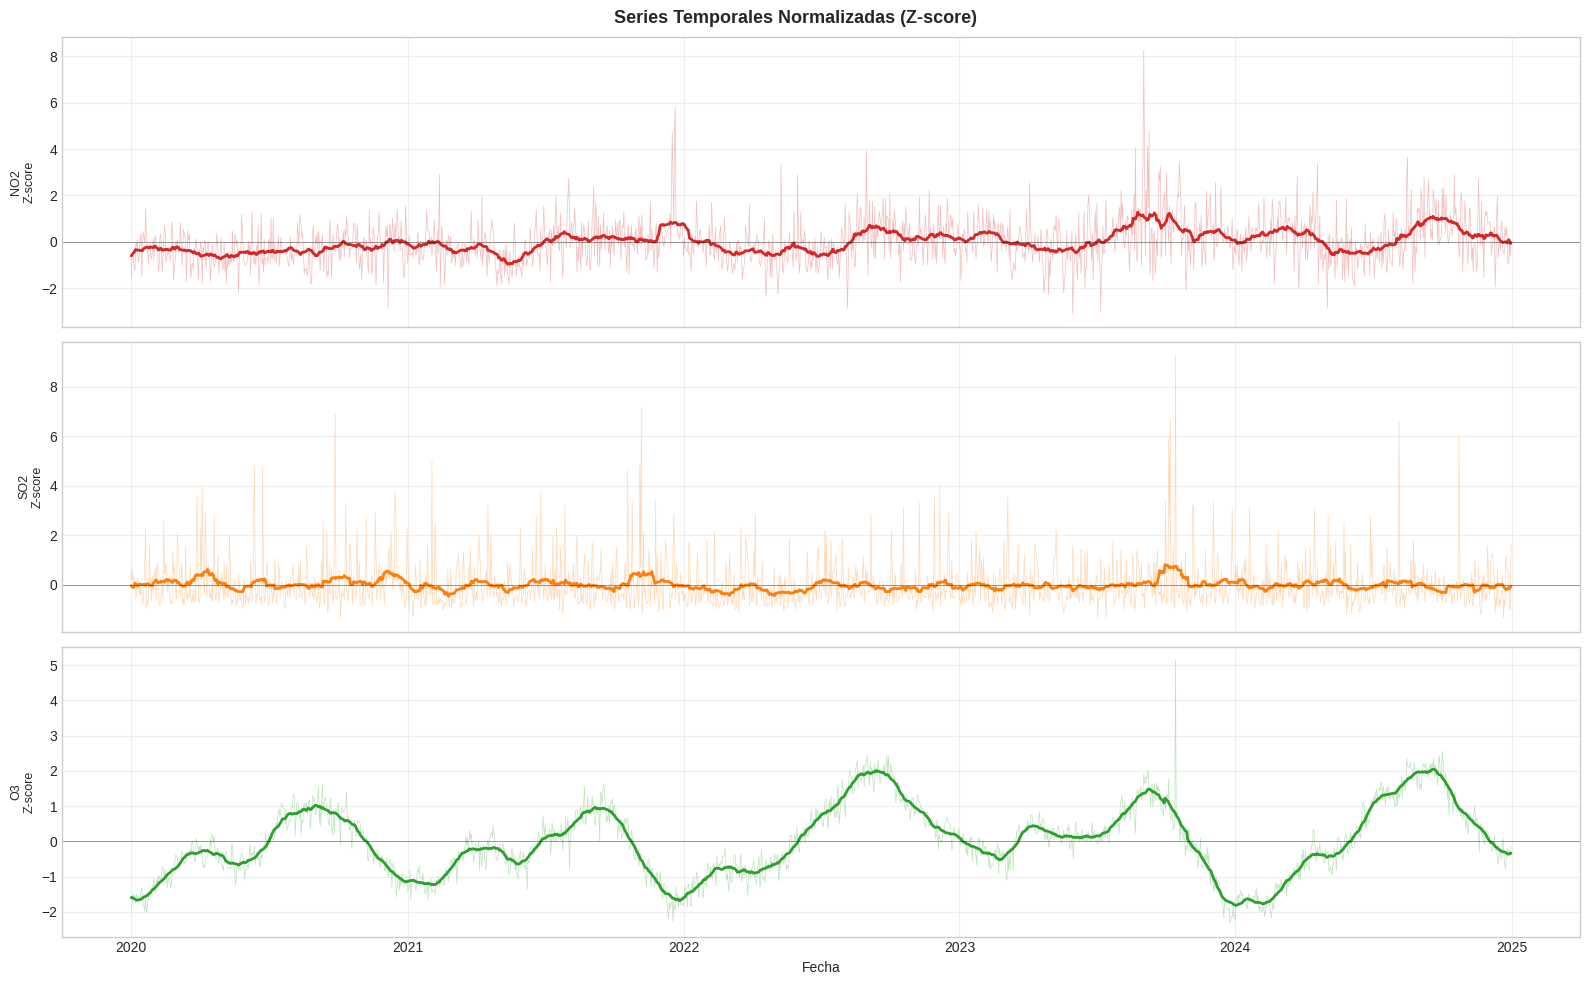

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Series Temporales Normalizadas (Z-score)', fontsize=13, weight='bold')

for i, p in enumerate(PRODUCTS):
    col = f'{p}_mean'; d = results['daily_df'].dropna(subset=[col])
    if len(d) < 10: continue
    z    = (d[col].values - np.nanmean(d[col].values)) / np.nanstd(d[col].values)
    roll = pd.Series(z).rolling(window=30, min_periods=5, center=True).mean()
    axes[i].plot(d['date'].values, z,    color=COLOR_MAP[p], alpha=0.3, lw=0.5)
    axes[i].plot(d['date'].values, roll, color=COLOR_MAP[p], lw=2)
    axes[i].axhline(0, color='black', lw=0.5, alpha=0.5)
    axes[i].set_ylabel(f'{p}\nZ-score', fontsize=9); axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'fig3_2_comparativa_normalizada.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## 📊 Bloque N — Influencia de Nubes

### Fig N1 · Mapa de píxeles válidos (cloud < 0.3)

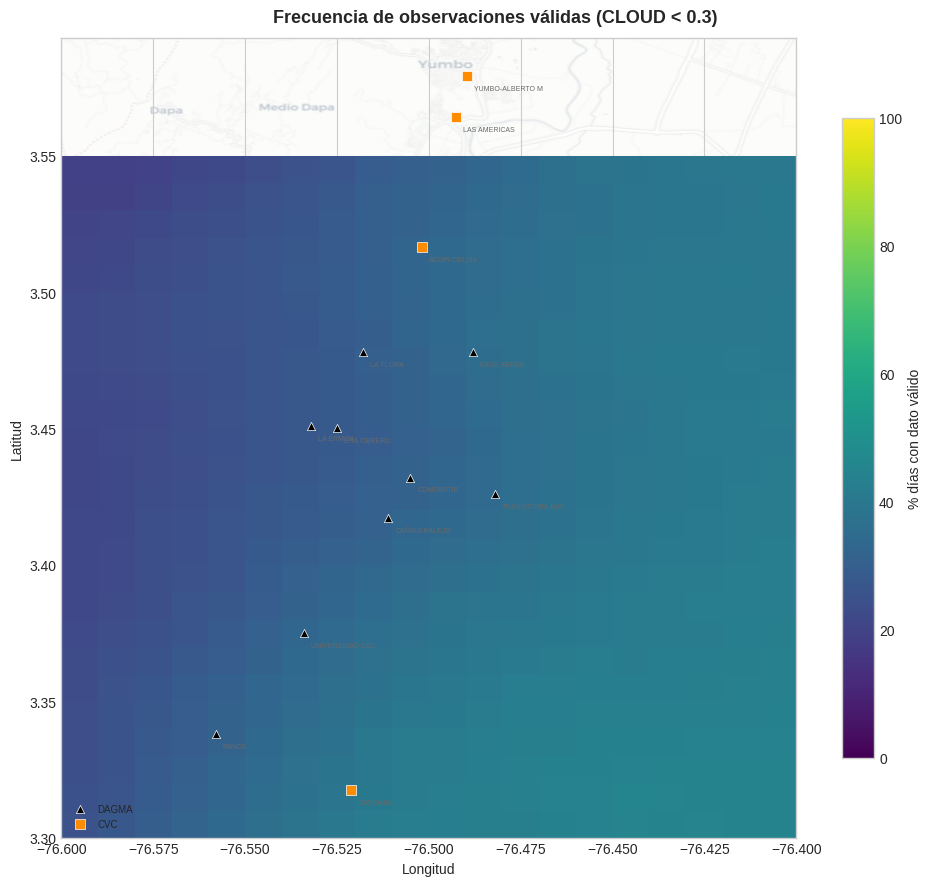

In [24]:
vc    = results['valid_pixel_count']
total = results['total_days_read']
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
pct = np.full_like(vc[rs, cs_sl], np.nan)
m   = vc[rs, cs_sl] > 0
pct[m] = vc[rs, cs_sl][m] / total * 100
lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('Frecuencia de observaciones válidas (CLOUD < 0.3)', fontsize=13, weight='bold')
im = ax.pcolormesh(lon_g, lat_g, pct, cmap='viridis', shading='auto', vmin=0, vmax=100)
add_stations_to_map(ax, stations_gdf, True); add_basemap(ax, CALI_BOUNDS, 12)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.colorbar(im, ax=ax, label='% días con dato válido', shrink=0.8)
ax.legend(loc='lower left', fontsize=7)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figN1_map_valid_pixels.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig N2 · Cobertura espacial diaria — serie temporal

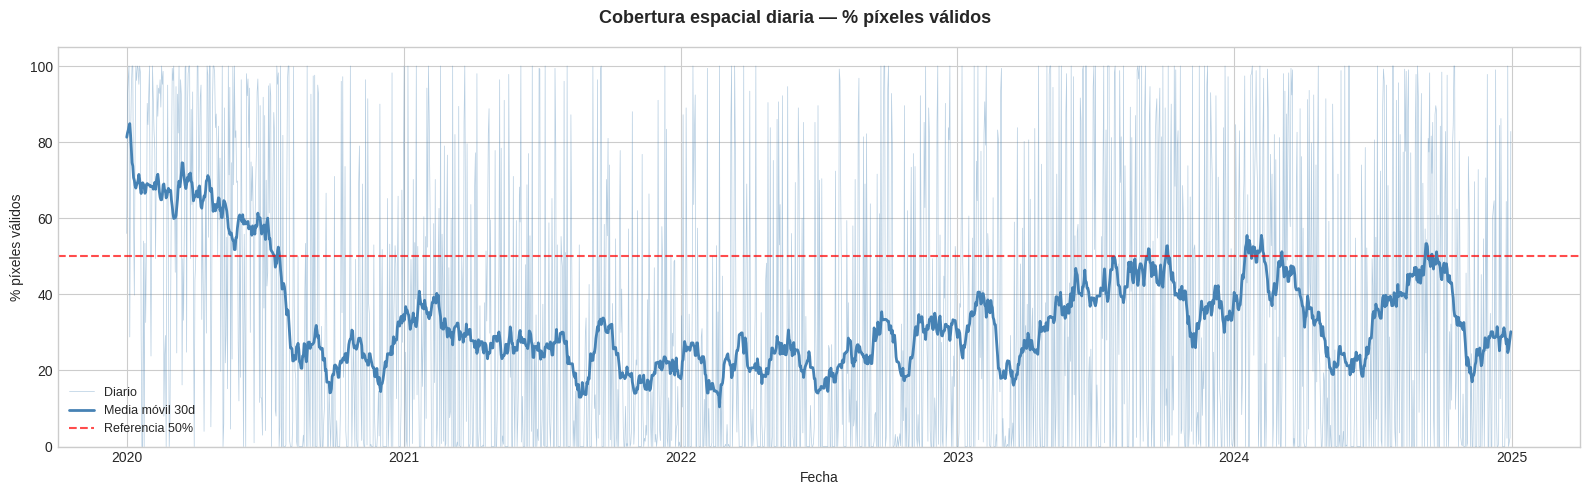

In [25]:
cov  = results['cov_df'].dropna(subset=['coverage_pct']).copy()
dates, cov_vals = cov['date'].values, cov['coverage_pct'].values
roll = compute_rolling_mean(cov_vals, 30)

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Cobertura espacial diaria — % píxeles válidos', fontsize=13, weight='bold')
ax.plot(dates, cov_vals, color='steelblue', alpha=0.4, lw=0.5, label='Diario')
ax.plot(dates, roll,     color='steelblue', lw=2,     label='Media móvil 30d')
ax.axhline(50, color='red', ls='--', lw=1.5, alpha=0.7, label='Referencia 50%')
ax.set_ylabel('% píxeles válidos'); ax.set_xlabel('Fecha')
ax.legend(loc='lower left', fontsize=9); ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figN2_coverage_timeseries.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig N3 · Sesgo S5P vs DAGMA en función de la nube

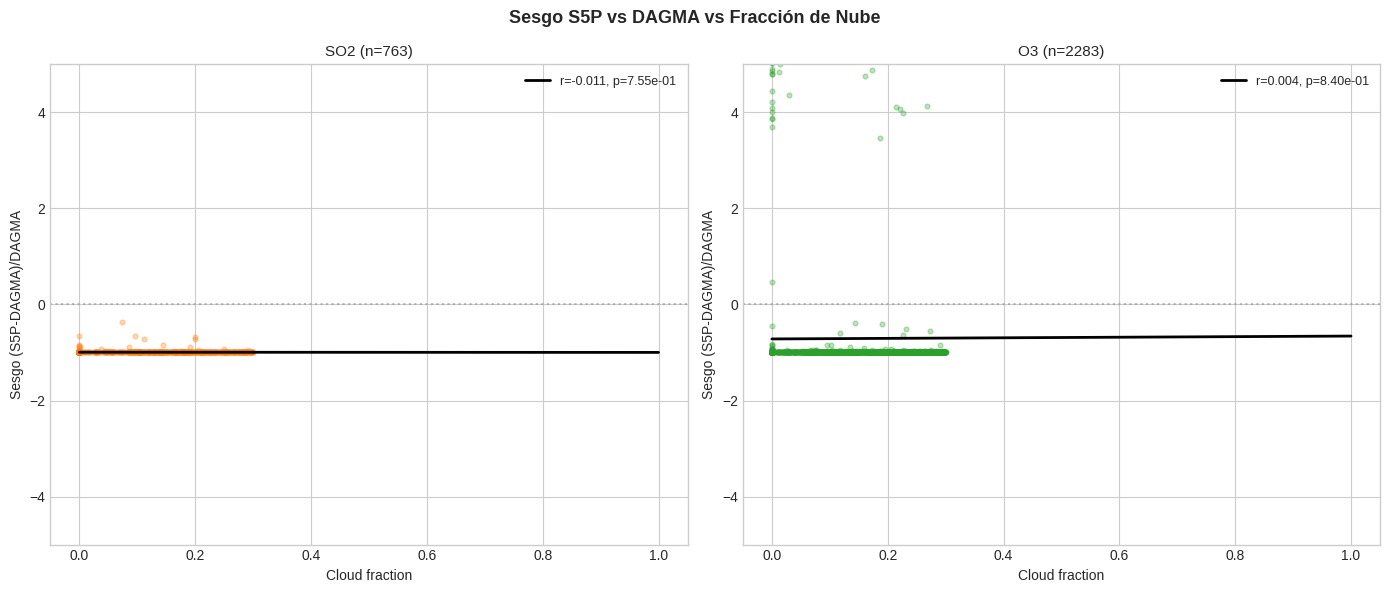

In [26]:
csv_files = sorted(DAGMA_RAW_DIR.glob('g4t8_*.csv'))
if not csv_files:
    print("⚠️  Sin archivos DAGMA — se omite figN3")
else:
    usecols = ['nombre_est','msfl_code','med_concentracion_estandar','med_fecha_inicio','latitud','longitud']
    dtype   = {'nombre_est':str,'msfl_code':str,'med_concentracion_estandar':float,
                'med_fecha_inicio':str,'latitud':float,'longitud':float}
    chunks = []
    for f in csv_files:
        try:
            for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=20000,
                                     encoding='utf-8', on_bad_lines='skip'):
                chunk = chunk[chunk['msfl_code'].isin(['SO2','O3'])].copy()
                if chunk.empty: continue
                chunk['fecha'] = pd.to_datetime(chunk['med_fecha_inicio'], errors='coerce').dt.date
                chunk['valor'] = pd.to_numeric(chunk['med_concentracion_estandar'], errors='coerce')
                chunk = chunk.dropna(subset=['fecha','valor'])
                chunks.append(chunk[['nombre_est','fecha','msfl_code','valor','latitud','longitud']])
        except: continue

    if not chunks:
        print("⚠️  Sin datos DAGMA válidos — se omite figN3")
    else:
        dagma       = pd.concat(chunks, ignore_index=True)
        dagma_daily = dagma.groupby(['nombre_est','fecha','msfl_code','latitud','longitud'],
                                    as_index=False)['valor'].mean()
        date_to_dir = {d[0].date(): d[4] for d in date_inventory}
        records = []
        for fecha in sorted(dagma_daily['fecha'].unique()):
            if fecha not in date_to_dir: continue
            day_dir = date_to_dir[fecha]
            cloud_data,_,_,_ = safe_read_raster(day_dir/'CLOUD.tif')
            if cloud_data is None: continue
            so2d = safe_read_raster(day_dir/'SO2.tif')[0] if (day_dir/'SO2.tif').exists() else None
            o3d  = safe_read_raster(day_dir/'O3.tif')[0]  if (day_dir/'O3.tif').exists()  else None
            if so2d is None and o3d is None: continue
            qmask = cloud_data <= CLOUD_THRESHOLD
            day_dagma = dagma_daily[dagma_daily['fecha']==fecha]
            for _, dr in day_dagma.iterrows():
                row, col = lonlat_to_pixel(dr['longitud'], dr['latitud'])
                if not (0<=row<NROWS and 0<=col<NCOLS): continue
                if not qmask[row, col]: continue
                s5p_val = None
                if dr['msfl_code'] == 'SO2' and so2d is not None: s5p_val = so2d[row, col]
                elif dr['msfl_code'] == 'O3' and o3d is not None: s5p_val = o3d[row, col]
                if s5p_val is None or s5p_val <= 0 or dr['valor'] <= 0: continue
                records.append({'fecha':fecha, 'variable':dr['msfl_code'],
                                's5p':s5p_val, 'dagma':dr['valor'], 'cloud':cloud_data[row, col]})

        if not records:
            print("⚠️  Sin pares S5P-DAGMA encontrados — se omite figN3")
        else:
            mdf = pd.DataFrame(records)
            mdf['bias'] = (mdf['s5p'] - mdf['dagma']) / mdf['dagma']
            mdf = mdf[(mdf['bias']>-10) & (mdf['bias']<10)]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            fig.suptitle('Sesgo S5P vs DAGMA vs Fracción de Nube', fontsize=13, weight='bold')
            for ax, var in [(ax1,'SO2'),(ax2,'O3')]:
                dv = mdf[mdf['variable']==var]
                if len(dv) < 5:
                    ax.text(0.5,0.5,f'{var}: n={len(dv)}',ha='center',va='center',transform=ax.transAxes); continue
                sl, ic, rv, pv, _ = stats.linregress(dv['cloud'], dv['bias'])
                ax.scatter(dv['cloud'], dv['bias'], alpha=0.3, s=12, c=COLOR_MAP.get(var,'gray'))
                xf = np.linspace(0,1,100); ax.plot(xf, sl*xf+ic, 'k-', lw=2, label=f'r={rv:.3f}, p={pv:.2e}')
                ax.axhline(0, color='gray', ls=':', alpha=0.5)
                ax.set_xlabel('Cloud fraction'); ax.set_ylabel('Sesgo (S5P-DAGMA)/DAGMA')
                ax.set_title(f'{var} (n={len(dv)})', fontsize=11)
                ax.legend(fontsize=9); ax.set_ylim(-5,5)

            fig.tight_layout()
            fig.savefig(OUTPUT_DIR/'figN3_cloud_vs_bias.png', dpi=DPI, bbox_inches='tight')
            plt.show(); plt.close(fig)


---
## 📊 Bloque T — Análisis Temporal

### Fig T1 · Autocorrelación temporal

  NO2: lag óptimo=1
  SO2: lag óptimo=1
  O3: lag óptimo=30


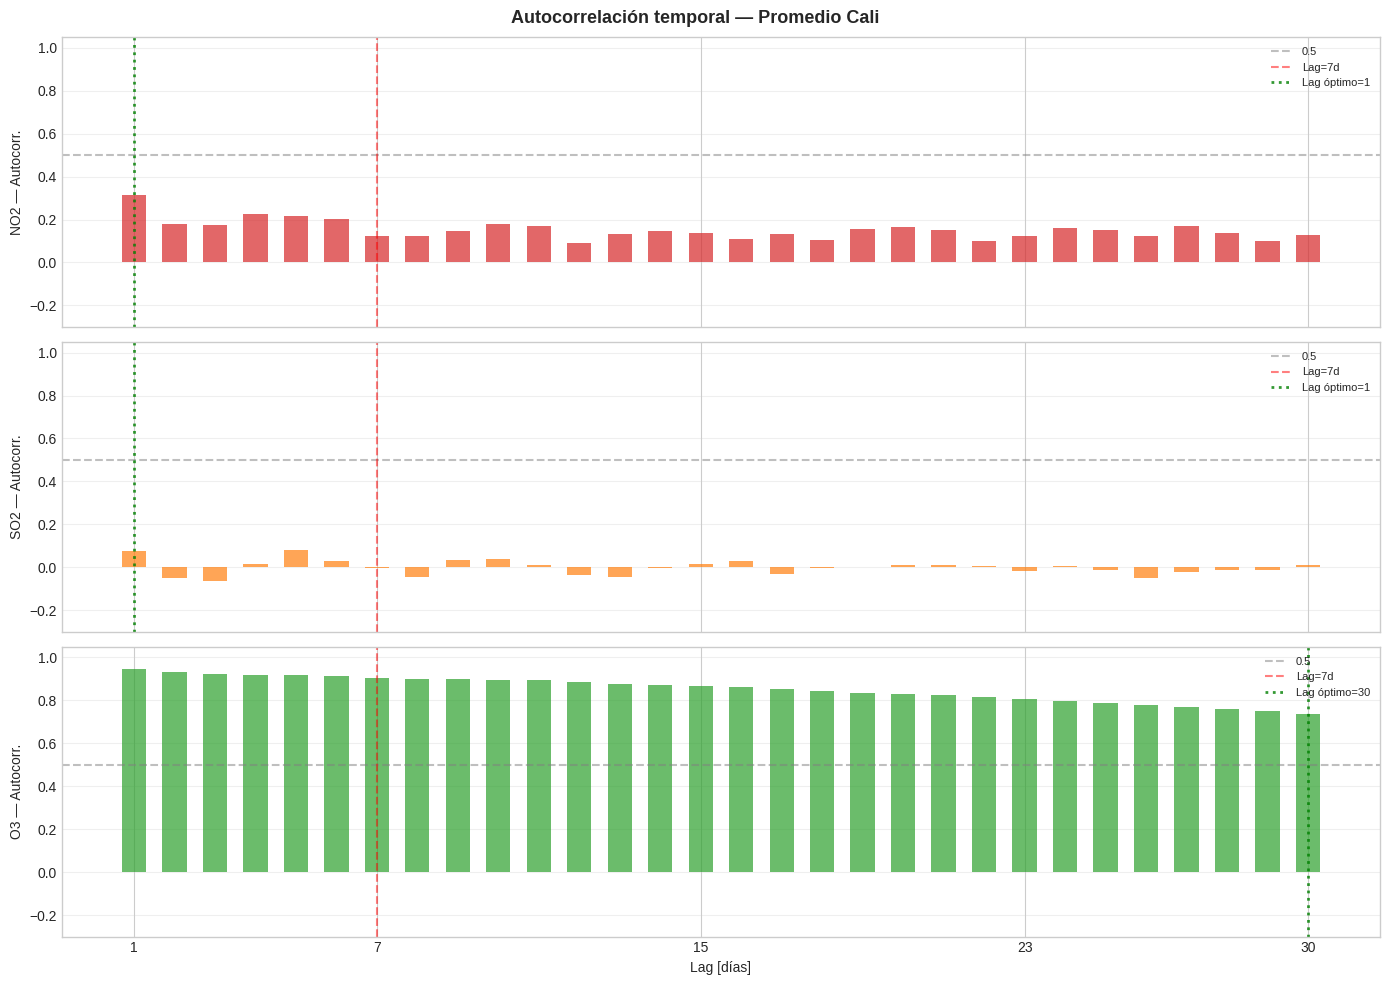

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Autocorrelación temporal — Promedio Cali', fontsize=13, weight='bold')

for i, prod in enumerate(PRODUCTS):
    col = f'{prod}_mean'; d = results['daily_df'].dropna(subset=[col])
    if len(d) < 30:
        axes[i].text(0.5,0.5,f'{prod}: insuficientes',ha='center',va='center',transform=axes[i].transAxes)
        continue
    v  = d[col].values * MOL_TO_UMOL
    ac = [stats.pearsonr(v[:-lag], v[lag:])[0] if lag < len(v) else np.nan for lag in range(1, 31)]
    lags = np.arange(1, 31); ac = np.array(ac)
    opt  = next((l for l, a in zip(lags, ac) if not np.isnan(a) and a < 0.5), 30)
    axes[i].bar(lags, ac, color=COLOR_MAP[prod], alpha=0.7, width=0.6)
    axes[i].axhline(0.5, color='gray', ls='--', alpha=0.5, label='0.5')
    axes[i].axvline(7,   color='red',  ls='--', alpha=0.5, label='Lag=7d')
    axes[i].axvline(opt, color='green',ls=':', lw=2, alpha=0.8, label=f'Lag óptimo={opt}')
    axes[i].set_ylabel(f'{prod} — Autocorr.'); axes[i].legend(fontsize=8, loc='upper right')
    axes[i].set_ylim(-0.3, 1.05); axes[i].grid(axis='y', alpha=0.3)
    print(f'  {prod}: lag óptimo={opt}')

axes[-1].set_xlabel('Lag [días]'); axes[-1].set_xticks([1,7,15,23,30])
fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figT1_autocorrelation.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig T2 · Tendencia anual NO₂ por píxel

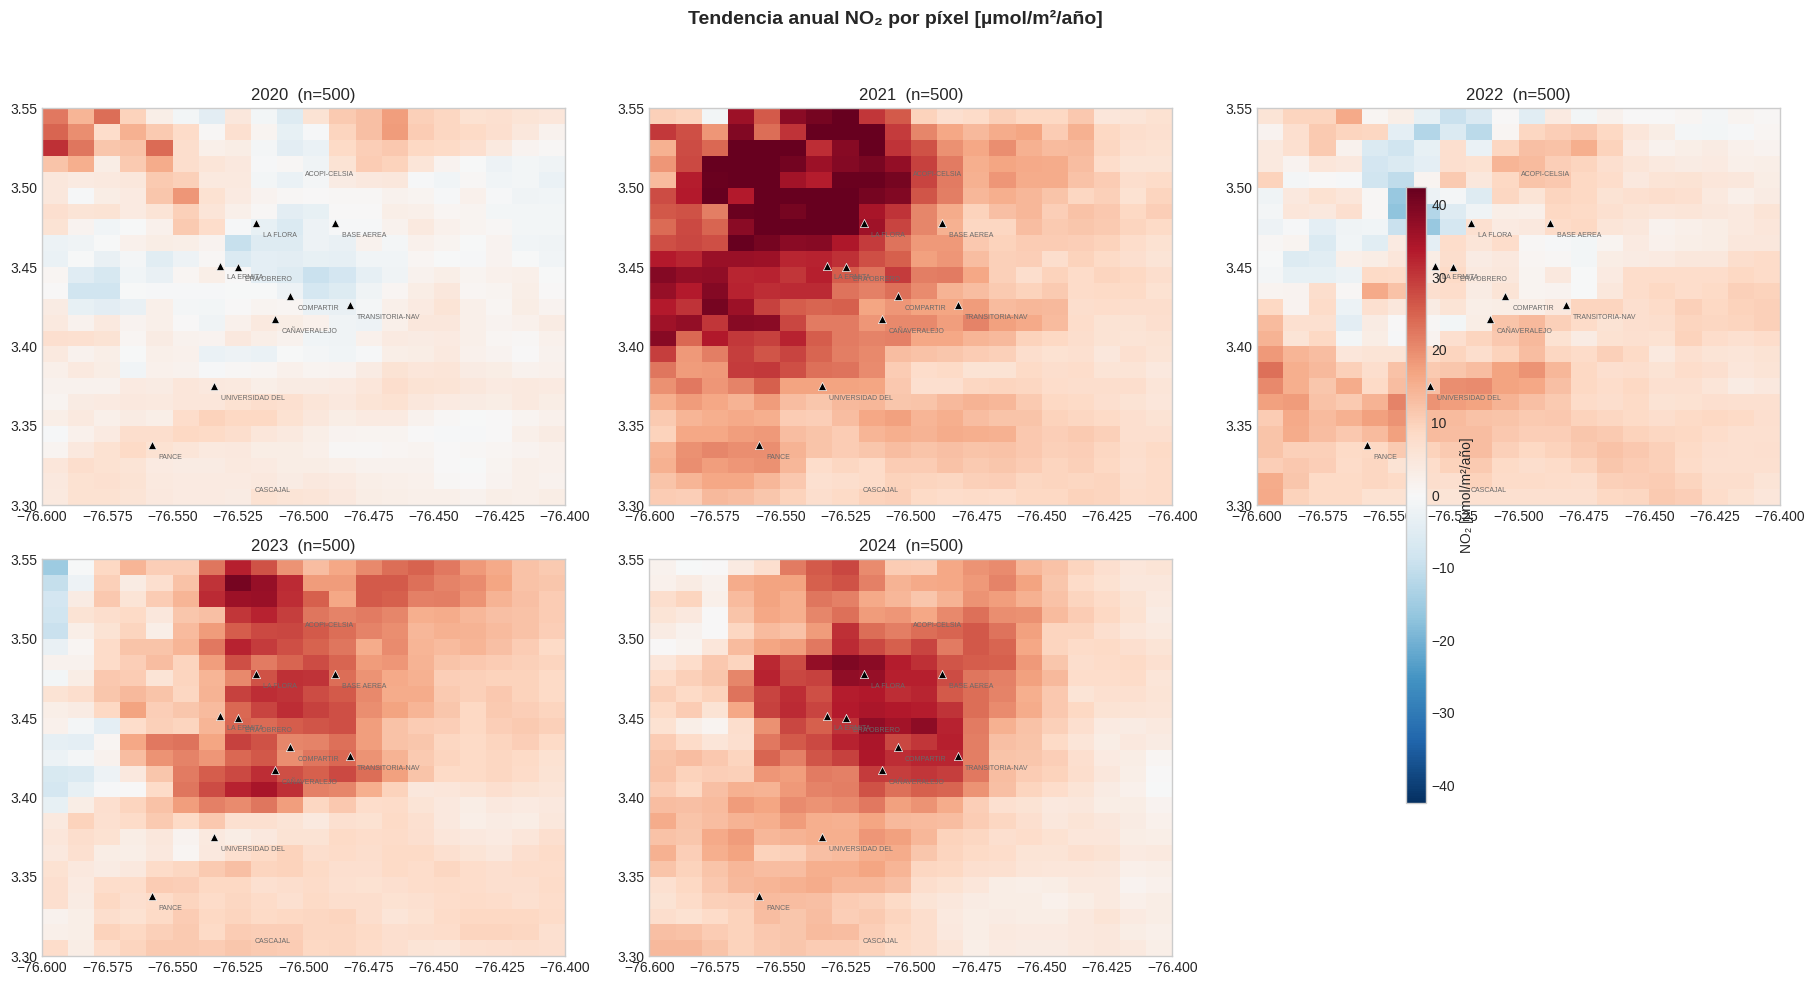

In [28]:
tm  = results['trend_maps']
yrs = sorted([y for y in YEARS if y in tm and np.any(~np.isnan(tm[y]))])
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)
ncols_p, nrows_p = min(3, len(yrs)), int(np.ceil(len(yrs)/3))

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(6*ncols_p, 5*nrows_p), squeeze=False)
fig.suptitle('Tendencia anual NO₂ por píxel [µmol/m²/año]', fontsize=14, weight='bold')
vmax = max(np.nanpercentile(tm[y][rs,cs_sl], 95) for y in yrs); vmin = -vmax

for i, y in enumerate(yrs):
    r, c = i//ncols_p, i%ncols_p; ax = axes[r][c]
    t  = np.ma.masked_where(np.isnan(tm[y][rs,cs_sl]), tm[y][rs,cs_sl])
    im = ax.pcolormesh(lon_g, lat_g, t, cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
    add_stations_to_map(ax, stations_gdf, False); add_basemap(ax, CALI_BOUNDS, 12)
    ax.set_title(f'{y}  (n={np.sum(~np.isnan(tm[y][rs,cs_sl]))})')

for j in range(len(yrs), nrows_p*ncols_p):
    axes[j//ncols_p][j%ncols_p].set_visible(False)

plt.colorbar(im, ax=axes.ravel().tolist(), label='NO₂ [µmol/m²/año]', shrink=0.8, aspect=30)
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(OUTPUT_DIR/'figT2_trend_maps.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig T3 · Ciclo semanal NO₂ — Centro vs Zona industrial

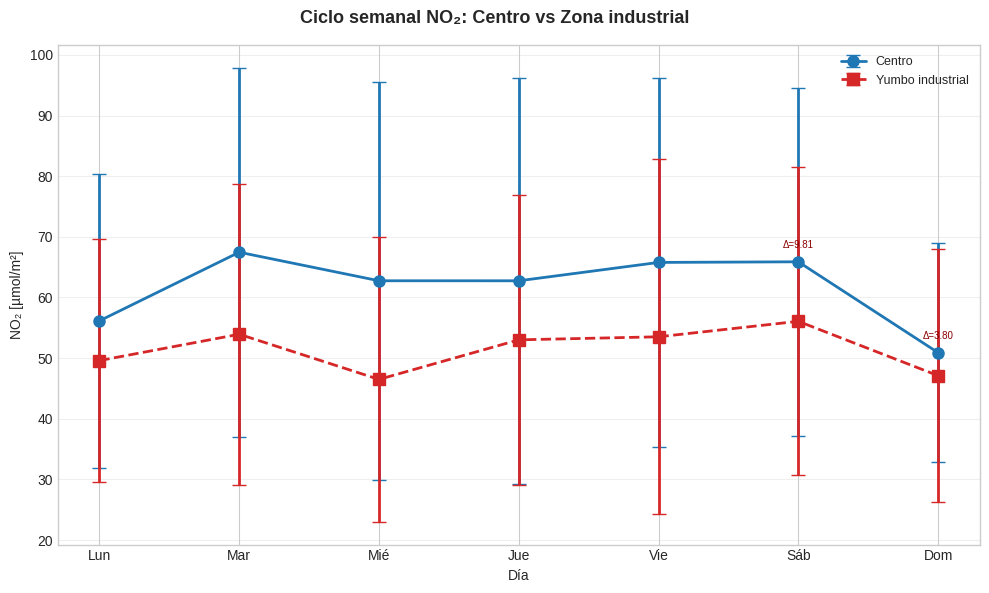

In [29]:
centro_b = {'left':-76.53,'right':-76.52,'bottom':3.45,'top':3.46}
yumbo_b  = {'left':-76.51,'right':-76.49,'bottom':3.50,'top':3.58}
crs, ccs = bounds_to_slice(centro_b); yrs2, ycs = bounds_to_slice(yumbo_b)

d2d = {d[0].date(): (d[0], d[4]) for d in date_inventory}
cw, yw = defaultdict(list), defaultdict(list)

for fecha, (dt, day_dir) in sorted(d2d.items()):
    np_ = day_dir/'NO2.tif'; cp_ = day_dir/'CLOUD.tif'
    if not np_.exists() or not cp_.exists(): continue
    nd,_,_,_ = safe_read_raster(np_); cd,_,_,_ = safe_read_raster(cp_)
    if nd is None or cd is None: continue
    qm = cd <= CLOUD_THRESHOLD; wd = dt.weekday()
    cvv = nd[crs,ccs][(qm[crs,ccs]) & (nd[crs,ccs] > 0)]
    if len(cvv) > 0: cw[wd].append(np.nanmean(cvv)*MOL_TO_UMOL)
    yvv = nd[yrs2,ycs][(qm[yrs2,ycs]) & (nd[yrs2,ycs] > 0)]
    if len(yvv) > 0: yw[wd].append(np.nanmean(yvv)*MOL_TO_UMOL)

ds  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
cm  = [np.nanmean(np.array(cw.get(d,[]))) if cw.get(d) else np.nan for d in range(7)]
cs_ = [np.nanstd (np.array(cw.get(d,[]))) if cw.get(d) else np.nan for d in range(7)]
ym  = [np.nanmean(np.array(yw.get(d,[]))) if yw.get(d) else np.nan for d in range(7)]
ys_ = [np.nanstd (np.array(yw.get(d,[]))) if yw.get(d) else np.nan for d in range(7)]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Ciclo semanal NO₂: Centro vs Zona industrial', fontsize=13, weight='bold')
ax.errorbar(range(7), cm, yerr=cs_, fmt='o-',  color='#1f77b4', lw=2, markersize=8, capsize=5, label='Centro')
ax.errorbar(range(7), ym, yerr=ys_, fmt='s--', color='#d62728', lw=2, markersize=8, capsize=5, label='Yumbo industrial')
ax.set_xticks(range(7)); ax.set_xticklabels(ds)
ax.set_ylabel('NO₂ [µmol/m²]'); ax.set_xlabel('Día')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for d_i in [5,6]:
    if not np.isnan(cm[d_i]) and not np.isnan(ym[d_i]):
        ax.annotate(f'Δ={abs(cm[d_i]-ym[d_i]):.2f}', (d_i, max(cm[d_i],ym[d_i])),
                    textcoords="offset points", xytext=(0,10), fontsize=7, ha='center', color='darkred')

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figT3_weekly_industrial.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## 📊 Bloque I — Integración Multivariada (Viento)

### Fig I1 · NO₂ + Vectores de viento DAGMA

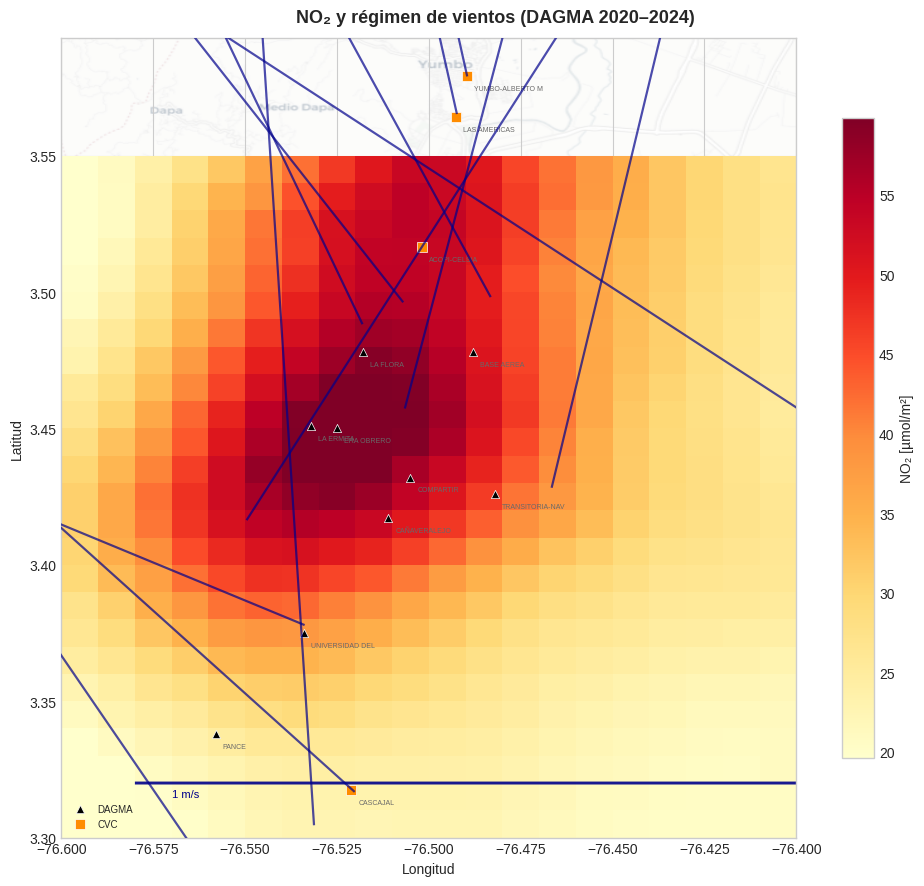

In [30]:
s, c = results['no2_sum'], results['no2_count']
csv_files = sorted(DAGMA_RAW_DIR.glob('g4t8_*.csv'))
if not csv_files:
    print("⚠️  Sin datos DAGMA — se omite figI1")
else:
    usecols = ['nombre_est','msfl_code','med_concentracion_estandar','med_fecha_inicio','latitud','longitud']
    dtype   = {'nombre_est':str,'msfl_code':str,'med_concentracion_estandar':float,
                'med_fecha_inicio':str,'latitud':float,'longitud':float}
    wind_chunks = []
    for f in csv_files:
        try:
            for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=20000,
                                     encoding='utf-8', on_bad_lines='skip'):
                chunk = chunk[chunk['msfl_code'].isin(['VViento','DViento'])].copy()
                if chunk.empty: continue
                wind_chunks.append(chunk[['nombre_est','latitud','longitud','msfl_code','med_concentracion_estandar']])
        except: continue

    if not wind_chunks:
        print("⚠️  Sin datos de viento — se omite figI1")
    else:
        wind = pd.concat(wind_chunks, ignore_index=True)
        wind.columns = ['nombre_est','latitud','longitud','msfl_code','valor']
        wind_agg = wind.groupby(['nombre_est','latitud','longitud','msfl_code'])['valor'].mean().reset_index()
        wind_p   = wind_agg.pivot_table(index=['nombre_est','latitud','longitud'],
                                        columns='msfl_code', values='valor').reset_index()

        if 'VViento' not in wind_p.columns or 'DViento' not in wind_p.columns:
            print("⚠️  Columnas de viento no encontradas — se omite figI1")
        else:
            rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
            f = np.full((NROWS,NCOLS), np.nan); m = c > 0; f[m] = s[m]/c[m]
            data = f[rs,cs_sl] * MOL_TO_UMOL
            lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)

            fig, ax = plt.subplots(figsize=(10, 9))
            fig.suptitle('NO₂ y régimen de vientos (DAGMA 2020–2024)', fontsize=13, weight='bold')
            vmin, vmax = np.nanpercentile(data, 2), np.nanpercentile(data, 98)
            im = ax.pcolormesh(lon_g, lat_g, data, cmap='YlOrRd', shading='auto', vmin=vmin, vmax=vmax)
            add_stations_to_map(ax, stations_gdf, True); add_basemap(ax, CALI_BOUNDS, 12)
            scale = 0.5
            for _, r in wind_p.iterrows():
                if np.isnan(r.get('VViento',np.nan)) or np.isnan(r.get('DViento',np.nan)): continue
                rad = np.radians(270 - r['DViento'])
                u  = r['VViento'] * np.cos(rad) * scale
                vc = r['VViento'] * np.sin(rad) * scale
                ax.quiver(r['longitud'], r['latitud'], u, vc,
                          angles='xy', scale_units='xy', scale=1,
                          color='darkblue', width=0.003, alpha=0.7, headwidth=4, headlength=5, zorder=11)
            ax.quiver(-76.58, 3.32, 1*scale, 0, angles='xy', scale_units='xy', scale=1,
                      color='darkblue', width=0.004, alpha=0.9)
            ax.text(-76.57, 3.315, '1 m/s', fontsize=8, color='darkblue')
            ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
            plt.colorbar(im, ax=ax, label='NO₂ [µmol/m²]', shrink=0.8)
            ax.legend(loc='lower left', fontsize=7)

            fig.tight_layout()
            fig.savefig(OUTPUT_DIR/'figI1_wind_bivariate.png', dpi=DPI, bbox_inches='tight')
            plt.show(); plt.close(fig)


---
## 📊 Bloque D — Dataset Multimodal

### Fig D1 · Distribución NO₂ por clase textual (percentiles)

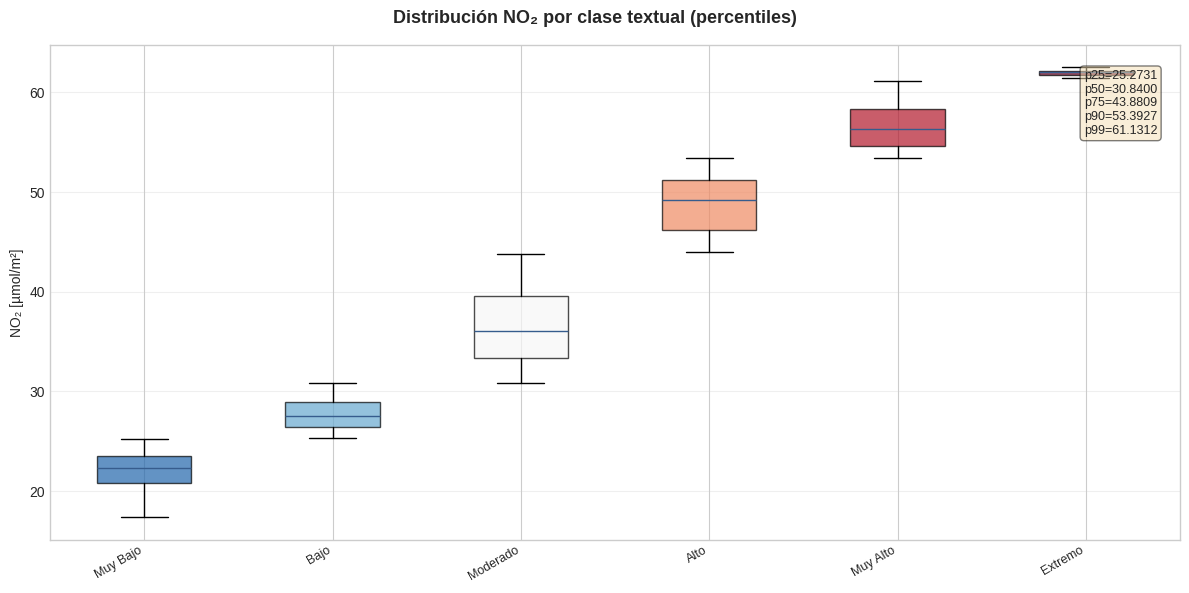

In [31]:
s, c = results['no2_sum'], results['no2_count']
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
f = np.full((NROWS, NCOLS), np.nan); m = c > 3; f[m] = s[m]/c[m]
vals = f[rs, cs_sl]; flat = vals[~np.isnan(vals)] * MOL_TO_UMOL

p25, p50, p75, p90, p99 = np.nanpercentile(flat, [25,50,75,90,99])
class_order  = ['Muy Bajo','Bajo','Moderado','Alto','Muy Alto','Extremo']
class_colors = ['#2166ac','#67a9cf','#f7f7f7','#ef8a62','#b2182b','#67001f']
thresholds   = [-np.inf, p25, p50, p75, p90, p99, np.inf]

data_by_class, actual_classes = [], []
for i in range(6):
    mask = (flat >= thresholds[i]) & (flat < thresholds[i+1])
    v = flat[mask]
    if len(v) > 0: data_by_class.append(v); actual_classes.append(class_order[i])

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Distribución NO₂ por clase textual (percentiles)', fontsize=13, weight='bold')
bp = ax.boxplot(data_by_class, patch_artist=True, showfliers=True,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], class_colors[:len(data_by_class)]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels(actual_classes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('NO₂ [µmol/m²]'); ax.grid(axis='y', alpha=0.3)
txt = f'p25={p25:.4f}\np50={p50:.4f}\np75={p75:.4f}\np90={p90:.4f}\np99={p99:.4f}'
ax.text(0.98, 0.95, txt, transform=ax.transAxes, fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figD1_textual_classes.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


### Fig D2 · K-Means clusters funcionales de NO₂ (k=5)

Extrayendo series para 500 píxeles...
  200/1827 fechas...
  400/1827 fechas...
  600/1827 fechas...
  800/1827 fechas...
  1000/1827 fechas...
  1200/1827 fechas...
  1400/1827 fechas...
  1600/1827 fechas...
  1800/1827 fechas...
499 píxeles con ≥100 días válidos


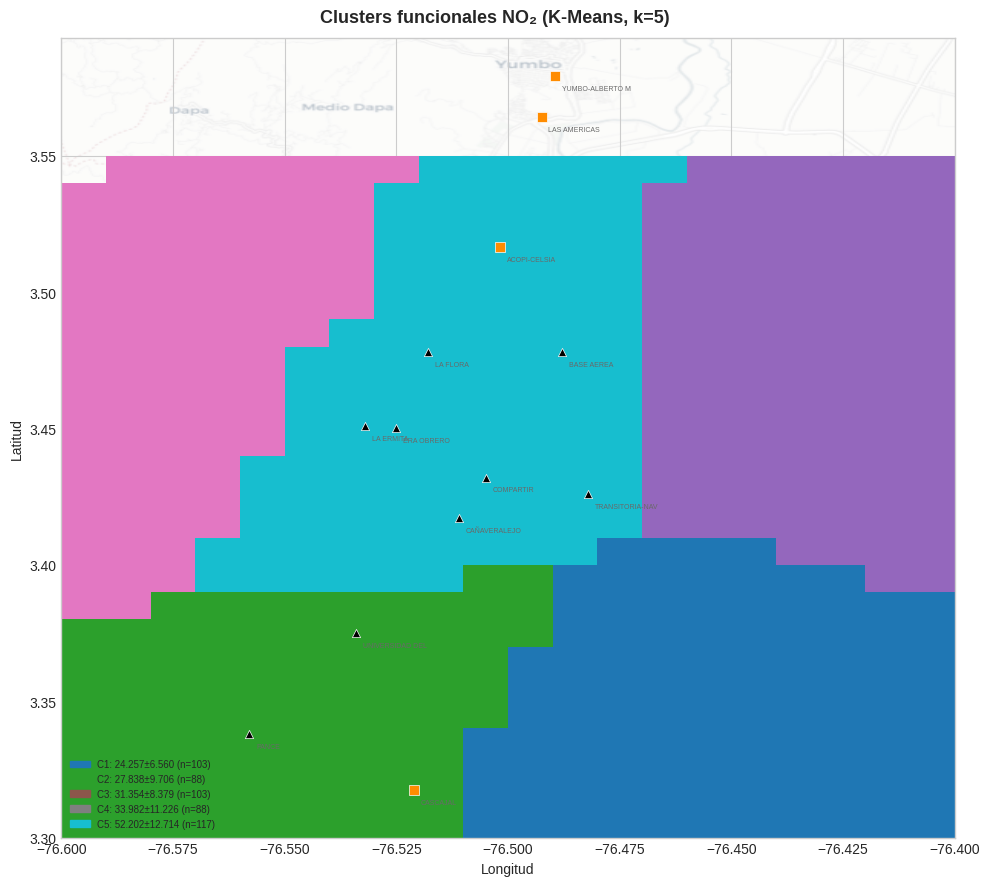

In [32]:
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
nc        = results['no2_count'][rs, cs_sl]
valid     = np.argwhere(nc > 10)
n_sample  = min(1000, len(valid))

rng     = np.random.RandomState(42)
sampled = valid[rng.choice(len(valid), size=n_sample, replace=False)]
print(f'Extrayendo series para {n_sample} píxeles...')

d2d = {d[0].date(): (d[0], d[4]) for d in date_inventory}
sd  = sorted(d2d.keys())
ts  = np.full((n_sample, len(sd)), np.nan)

for ti, fecha in enumerate(sd):
    dt, day_dir = d2d[fecha]
    np_ = day_dir/'NO2.tif'; cp_ = day_dir/'CLOUD.tif'
    if not np_.exists() or not cp_.exists(): continue
    nd,_,_,_ = safe_read_raster(np_); cd,_,_,_ = safe_read_raster(cp_)
    if nd is None or cd is None: continue
    qm = cd[rs, cs_sl] <= CLOUD_THRESHOLD; ndc = nd[rs, cs_sl]
    for pi, (pr, pc) in enumerate(sampled):
        if qm[pr, pc] and ndc[pr, pc] > 0: ts[pi, ti] = ndc[pr, pc] * MOL_TO_UMOL
    if (ti+1)%200==0: print(f'  {ti+1}/{len(sd)} fechas...')

nv   = np.sum(~np.isnan(ts), axis=1); good = nv >= 100
ts, sampled = ts[good], sampled[good]
print(f'{len(ts)} píxeles con ≥100 días válidos')

ts_filled = ts.copy()
for i in range(len(ts_filled)):
    rm = np.nanmean(ts_filled[i]); ts_filled[i, np.isnan(ts_filled[i])] = rm

scaler  = StandardScaler(); ts_norm = scaler.fit_transform(ts_filled.T).T
k       = 5
kmeans  = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
labels  = kmeans.fit_predict(ts_norm)

profiles = {cl: {'mean': np.nanmean(ts_filled[labels==cl]),
                 'std':  np.nanstd (ts_filled[labels==cl]),
                 'n':    int((labels==cl).sum())} for cl in range(k)}
sorted_c = sorted(profiles.items(), key=lambda x: x[1]['mean'])

cmap_arr = np.full((rs.stop-rs.start, cs_sl.stop-cs_sl.start), np.nan)
cluster_names = {}
for nc_, (oc_, prof) in enumerate(sorted_c):
    for pr, pc in sampled[labels==oc_]: cmap_arr[pr, pc] = nc_
    cluster_names[nc_] = f'C{nc_+1}: {prof["mean"]:.3f}±{prof["std"]:.3f} (n={prof["n"]})'

lons, lats = pixel_centers(CALI_BOUNDS); lon_g, lat_g = np.meshgrid(lons, lats)
cmap_d = plt.cm.tab10
bnds   = np.arange(-0.5, k+0.5, 1); norm = matplotlib.colors.BoundaryNorm(bnds, cmap_d.N)

fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('Clusters funcionales NO₂ (K-Means, k=5)', fontsize=13, weight='bold')
im = ax.pcolormesh(lon_g, lat_g, cmap_arr, cmap=cmap_d, norm=norm, shading='auto')
add_stations_to_map(ax, stations_gdf, True); add_basemap(ax, CALI_BOUNDS, 12)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
legend_handles = [Patch(color=cmap_d(nc_/(k-1)), label=cluster_names[nc_])
                  for nc_ in sorted(cluster_names)]
ax.legend(handles=legend_handles, loc='lower left', fontsize=7, framealpha=0.9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR/'figD2_kmeans_clusters.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## 📊 Panel Resumen

### Fig Extra · Panel resumen EDA (3×3)

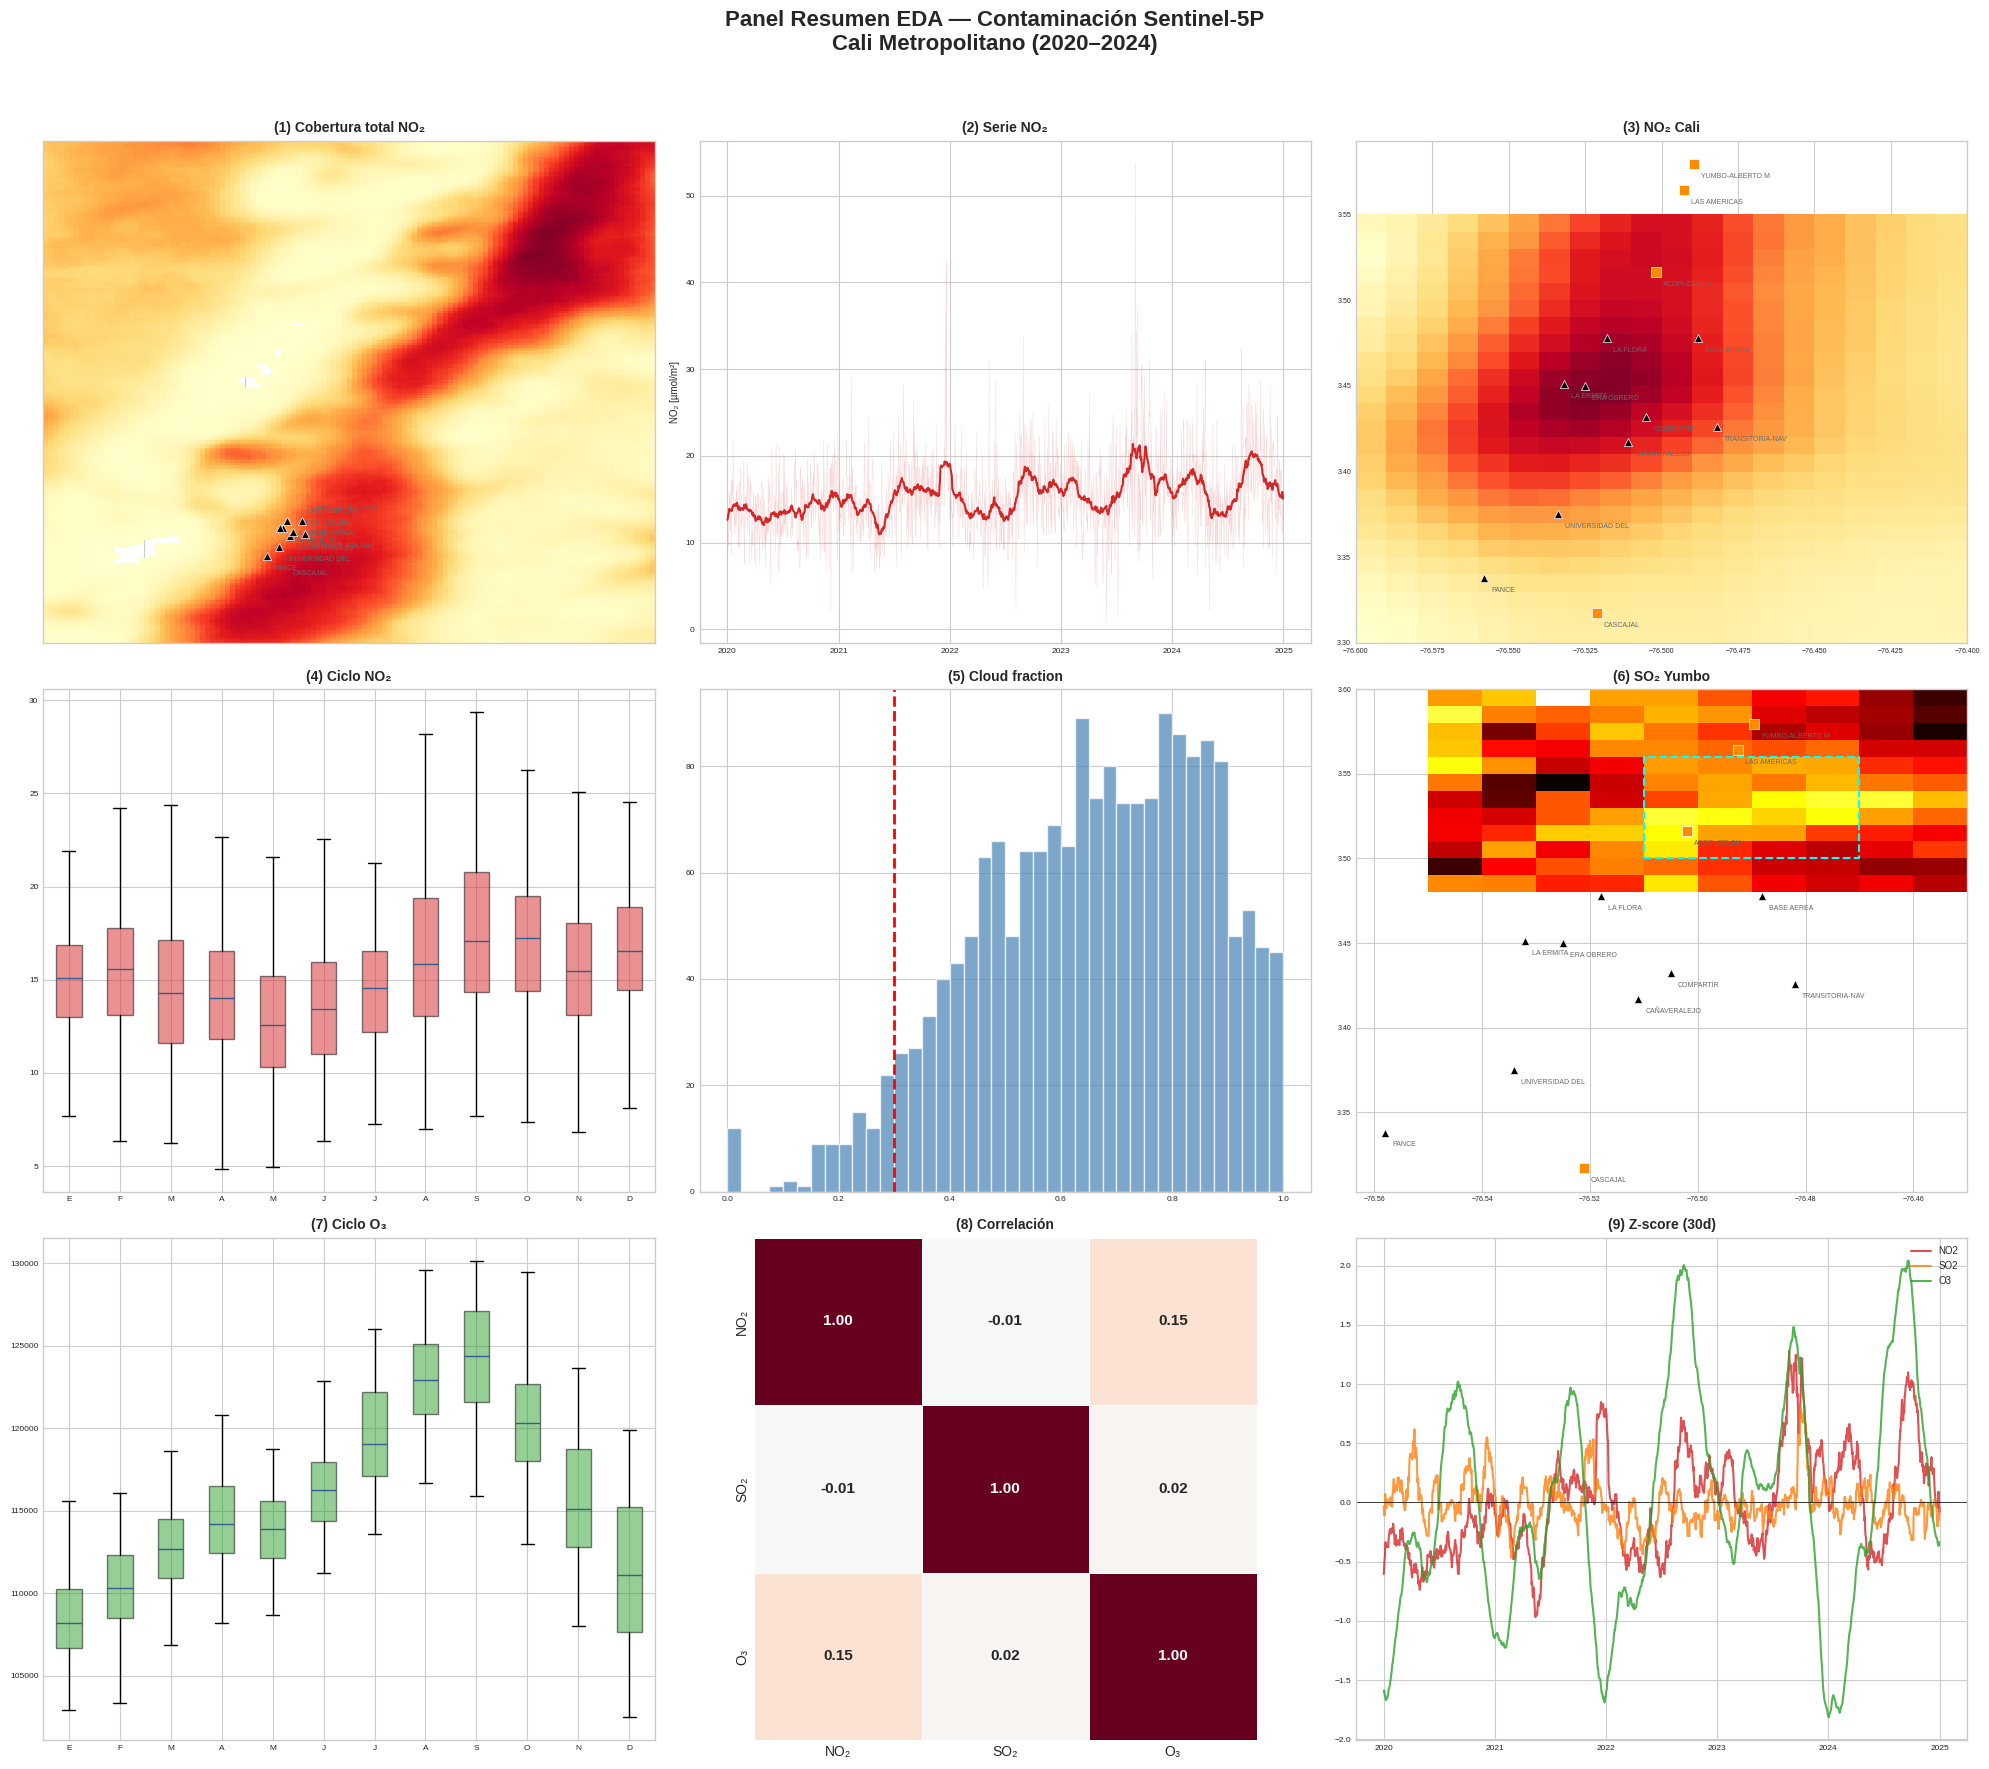

In [33]:
df = results['daily_df']
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Panel Resumen EDA — Contaminación Sentinel-5P\nCali Metropolitano (2020–2024)',
             fontsize=16, weight='bold', y=0.98)
lons_f, lats_f = pixel_centers(); lon_g, lat_g = np.meshgrid(lons_f, lats_f)

# 1 Cobertura total
ax1 = fig.add_subplot(3,3,1)
ct  = sum(results['cover_by_year'].values())
ax1.pcolormesh(lon_g, lat_g, np.ma.masked_where(ct<=0, ct), cmap='YlOrRd', shading='auto')
add_stations_to_map(ax1, stations_gdf, False)
ax1.set_title('(1) Cobertura total NO₂', fontsize=10, weight='bold')
ax1.set_xticklabels([]); ax1.set_yticklabels([])

# 2 Serie NO₂
ax2 = fig.add_subplot(3,3,2)
d   = df.dropna(subset=['NO2_mean'])
if len(d):
    v  = d['NO2_mean'].values*MOL_TO_UMOL
    rl = pd.Series(v).rolling(30, min_periods=5, center=True).mean()
    ax2.plot(d['date'].values, v,  color=COLOR_NO2, alpha=0.2, lw=0.3)
    ax2.plot(d['date'].values, rl, color=COLOR_NO2, lw=1.5)
    ax2.set_ylabel('NO₂ [µmol/m²]', fontsize=7)
ax2.set_title('(2) Serie NO₂', fontsize=10, weight='bold'); ax2.tick_params(labelsize=6)

# 3 Mapa NO₂ Cali
ax3 = fig.add_subplot(3,3,3)
rs, cs_sl = bounds_to_slice(CALI_BOUNDS)
f = np.full((NROWS,NCOLS),np.nan); m = results['no2_count']>0
f[m] = results['no2_sum'][m]/results['no2_count'][m]
clons, clats = pixel_centers(CALI_BOUNDS)
ax3.pcolormesh(*np.meshgrid(clons,clats), f[rs,cs_sl]*MOL_TO_UMOL, cmap='YlOrRd', shading='auto')
add_stations_to_map(ax3, stations_gdf, True)
ax3.set_title('(3) NO₂ Cali', fontsize=10, weight='bold'); ax3.tick_params(labelsize=5)

# 4 Ciclo NO₂
ax4 = fig.add_subplot(3,3,4)
if len(d):
    d_ = d.copy(); d_['m'] = d_['date'].dt.month
    md_ = [d_[d_['m']==mm]['NO2_mean'].dropna().values*MOL_TO_UMOL for mm in range(1,13)]
    bp  = ax4.boxplot(md_, patch_artist=True, showfliers=False)
    for p in bp['boxes']: p.set_facecolor(COLOR_NO2); p.set_alpha(0.5)
    ax4.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
ax4.set_title('(4) Ciclo NO₂', fontsize=10, weight='bold'); ax4.tick_params(labelsize=6)

# 5 Cloud
ax5 = fig.add_subplot(3,3,5)
ax5.hist(df['cloud_mean'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.7)
ax5.axvline(CLOUD_THRESHOLD, color='red', ls='--', lw=2)
ax5.set_title('(5) Cloud fraction', fontsize=10, weight='bold'); ax5.tick_params(labelsize=6)

# 6 SO₂ Yumbo
ax6 = fig.add_subplot(3,3,6)
yrs2, ycs = bounds_to_slice(YUMBO_BOUNDS)
sf = np.full((NROWS,NCOLS),np.nan); sm = results['so2_count']>0
sf[sm] = results['so2_sum'][sm]/results['so2_count'][sm]
ylons, ylats = pixel_centers(YUMBO_BOUNDS)
ax6.pcolormesh(*np.meshgrid(ylons,ylats), sf[yrs2,ycs]*MOL_TO_UMOL, cmap='hot', shading='auto')
add_stations_to_map(ax6, stations_gdf, True)
ax6.add_patch(Rectangle((-76.51,3.50),0.04,0.06,lw=1.5,edgecolor='cyan',facecolor='none',ls='--'))
ax6.set_title('(6) SO₂ Yumbo', fontsize=10, weight='bold'); ax6.tick_params(labelsize=5)

# 7 Ciclo O₃
ax7 = fig.add_subplot(3,3,7)
do  = df.dropna(subset=['O3_mean'])
if len(do):
    do_ = do.copy(); do_['m'] = do_['date'].dt.month
    md_o = [do_[do_['m']==mm]['O3_mean'].dropna().values*MOL_TO_UMOL for mm in range(1,13)]
    bp   = ax7.boxplot(md_o, patch_artist=True, showfliers=False)
    for p in bp['boxes']: p.set_facecolor(COLOR_O3); p.set_alpha(0.5)
    ax7.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
ax7.set_title('(7) Ciclo O₃', fontsize=10, weight='bold'); ax7.tick_params(labelsize=6)

# 8 Correlación
ax8   = fig.add_subplot(3,3,8)
cols_ = [f'{p}_mean' for p in PRODUCTS]; dc = df[cols_].dropna()
if len(dc)>10:
    cc = dc.corr(); cc.index=cc.columns=['NO₂','SO₂','O₃']
    sns.heatmap(cc, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, lw=0.5, cbar=False, ax=ax8,
                annot_kws={'fontsize':11,'fontweight':'bold'})
ax8.set_title('(8) Correlación', fontsize=10, weight='bold')

# 9 Z-score
ax9 = fig.add_subplot(3,3,9)
for p in PRODUCTS:
    col = f'{p}_mean'; dp = df.dropna(subset=[col])
    if len(dp)>10:
        z  = (dp[col].values - np.nanmean(dp[col].values)) / np.nanstd(dp[col].values)
        rl = pd.Series(z).rolling(30, min_periods=5, center=True).mean()
        ax9.plot(dp['date'].values, rl, color=COLOR_MAP[p], lw=1.5, label=p, alpha=0.8)
ax9.axhline(0, color='black', lw=0.5); ax9.legend(fontsize=7, loc='upper right')
ax9.set_title('(9) Z-score (30d)', fontsize=10, weight='bold'); ax9.tick_params(labelsize=6)

fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(OUTPUT_DIR/'fig_extra_panel_resumen.png', dpi=DPI, bbox_inches='tight')
plt.show(); plt.close(fig)


---
## ✅ Resumen de figuras generadas

In [34]:
figs = sorted(OUTPUT_DIR.glob('fig*.png'))
print(f'Figuras guardadas en: {OUTPUT_DIR}')
print(f'Total: {len(figs)} archivos\n')
for i, p in enumerate(figs, 1):
    print(f'  {i:2d}. {p.name}')


Figuras guardadas en: /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/sentinel5p
Total: 24 archivos

   1. fig1_1a_cobertura_anual.png
   2. fig1_1b_cobertura_temporal.png
   3. fig1_2_calidad_nube.png
   4. fig2_1a_no2_serie_temporal.png
   5. fig2_1b_no2_ciclo_estacional.png
   6. fig2_1c_no2_mapa_espacial.png
   7. fig2_1d_no2_vs_nubes.png
   8. fig2_2a_so2_mapa_yumbo.png
   9. fig2_2b_so2_eventos_extremos.png
  10. fig2_3a_o3_ciclo_estacional.png
  11. fig2_3b_o3_vs_no2_scatter.png
  12. fig2_3c_o3_mapa_espacial.png
  13. fig3_1_correlacion.png
  14. fig3_2_comparativa_normalizada.png
  15. figD1_textual_classes.png
  16. figD2_kmeans_clusters.png
  17. figI1_wind_bivariate.png
  18. figN1_map_valid_pixels.png
  19. figN2_coverage_timeseries.png
  20. figN3_cloud_vs_bias.png
  21. figT1_autocorrelation.png
  22. figT2_trend_maps.png
  23. figT3_weekly_industrial.png
  24. fig_extra_panel_resumen.png
